# **Problem Statement**

Hospital systems face significant financial penalties and reduced quality ratings under the Hospital Readmissions Reduction Program (HRRP) when diabetic patients are readmitted within 30 days of discharge. Clinical care teams often lack automated tools that can simultaneously query complex electronic health records (EHRs), run real-time predictive risk scoring, and synthesize high-risk factors into actionable, executive-level discharge plans.

# **How to Solve the Problem**

**Step 1: Install Dependencies & Setup Environment**

Set up the in-memory database, ML packages, and Groq API client.

**Step 2: Load Data & Initialize DuckDB**

Load the diabetic records into an in-memory DuckDB database and create the engineered feature table.

**Step 3: Train XGBoost with SHAP Explainability**

Train the classifier on the extracted SQL table and initialize the SHAP explainer to calculate local feature contributions.

**Step 4: Build the 3-Agent Workflow using Groq Compound**

Define the agent stack using Groq's groq/compound system for Agent 3.

**Step 5: Run the End-to-End Pipeline**

Execute the full 3-agent orchestration chain on a sample patient record.

**Step 6: BI Dashboarding, Cohort Visualizations & Cost-Benefit Analysis**

Generate cohort charts in Google Colab to visualize the underlying risk distribution. Perform a cost-benefit analysis of deploying this 3-agent system.

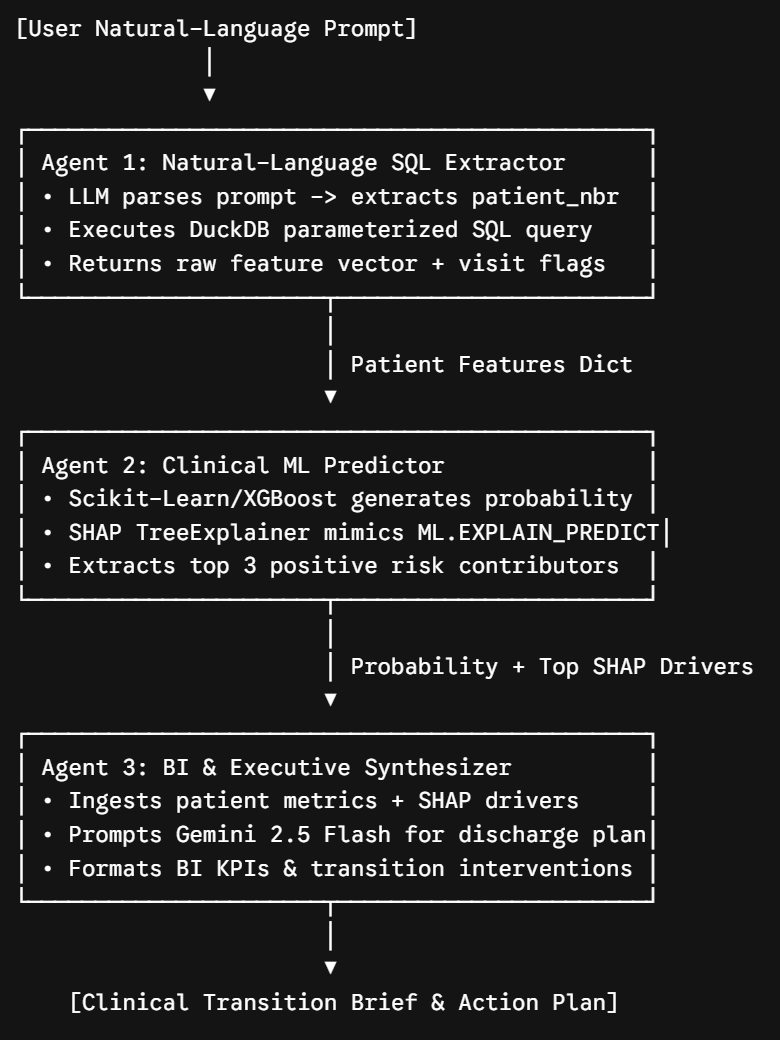

**Agent 1: Natural-Language SQL Extractor (Gemini + DuckDB)**

In BigQuery, this agent translates text to SQL and runs queries against cloud tables. In Google Colab, DuckDB serves as an in-memory SQL warehouse, and Gemini parses the user request into a targeted SQL query.

**Natural-Language Parsing:** Gemini extracts the target patient_nbr from freeform input (e.g., "Assess patient 12048 for early discharge").

**Parameterized Execution:** A parameterized SQL query runs against the DuckDB table to retrieve admissions history and calculate baseline flags (such as emergency visit frequency).


**Agent 2: Clinical ML Predictor (XGBoost + SHAP)**

In GCP, BigQuery ML executes ML.EXPLAIN_PREDICT to output prediction probabilities alongside feature attributions. In Google Colab, SHAP (TreeExplainer) replicates this functionality locally.

**Prediction:** Runs the patient's feature vector through the trained XGBoost model to calculate 30-day readmission risk ($P(\text{readmitted} = 1)$).

**Feature Attribution (SHAP):** Decomposes the model output into individual feature contributions, isolating the top 3 drivers pushing the patient toward high risk (e.g., number_emergency = 4, time_in_hospital = 8).

**Agent 3: BI & Executive Synthesizer (Gemini Flash)**

Agent 3 consumes the outputs from Agent 1 (raw vitals/emergency frequency) and Agent 2 (risk score and SHAP drivers), translating the raw data into an actionable clinical transition-of-care report.

**Clinical Synthesis:** Explains why the patient is at risk in plain medical language based on the SHAP drivers.

**Transition Care Plan:** Prescribes targeted interventions (e.g., pharmacy medication reconciliation if num_medications is high, rapid home health/telehealth if number_emergency is high).

**BI Reporting Metrics:** Summarizes key executive metrics to feed directly into operational hospital logs.




# **Step 1: Install Dependencies & Setup Environment**

Run this in the first Colab cell to set up the in-memory database, ML packages, and Groq API client.

**Avaiable Groq Models**

In [ ]:
import os
from google.colab import userdata
from groq import Groq

# Securely retrieve the key from Colab Secrets (Left sidebar > 🔑 icon)
# Ensure you have a secret named 'GROQ_API_KEY'
GROQ_API_KEY = userdata.get('GROQ_API_KEY')
client = Groq(api_key=GROQ_API_KEY)

# Minimal test to verify connectivity without printing sensitive data
response = client.chat.completions.create(
    model="groq/compound",
    messages=[
        {"role": "system", "content": "You are a Clinical BI Assistant."},
        {"role": "user", "content": "Verify system connection."}
    ]
)
print("System: Groq API Connection Secured and Verified.")

System: Groq API Connection Secured and Verified.


In [ ]:
import os
from google.colab import userdata
from groq import Groq

# Initialize Groq client with your API key from Colab secrets
client = Groq(api_key=userdata.get('GROQ_API_KEY'))

print('Listing available Groq models:')
# Access the list of model objects via the .data attribute of the ModelListResponse object
for model in client.models.list().data:
    print(model.id)

Listing available Groq models:
openai/gpt-oss-20b
openai/gpt-oss-120b
whisper-large-v3
meta-llama/llama-prompt-guard-2-86m
openai/gpt-oss-safeguard-20b
meta-llama/llama-prompt-guard-2-22m
qwen/qwen3.6-27b
groq/compound-mini
groq/compound
canopylabs/orpheus-v1-english
qwen/qwen3.8-27b
whisper-large-v3-turbo
canopylabs/orpheus-arabic-saudi
allam-2-7b


# **Step 2: Load Data & Initialize DuckDB**

Load the diabetic records into an in-memory DuckDB database and create the engineered feature table.

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "diabetic_data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "razanihababdellatif/diabetes-hospital-readmission-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("Records:", df)

/tmp/ipykernel_5637/2528837881.py:10: DeprecationWarning:

Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.



Using Colab cache for faster access to the 'diabetes-hospital-readmission-dataset' dataset.
Records:         encounter_id  patient_nbr             race  gender      age weight  \
0            2278392      8222157        Caucasian  Female   [0-10)      ?   
1             149190     55629189        Caucasian  Female  [10-20)      ?   
2              64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3             500364     82442376        Caucasian    Male  [30-40)      ?   
4              16680     42519267        Caucasian    Male  [40-50)      ?   
...              ...          ...              ...     ...      ...    ...   
101761     443847548    100162476  AfricanAmerican    Male  [70-80)      ?   
101762     443847782     74694222  AfricanAmerican  Female  [80-90)      ?   
101763     443854148     41088789        Caucasian    Male  [70-80)      ?   
101764     443857166     31693671        Caucasian  Female  [80-90)      ?   
101765     443867222    175429310        

# **Colummns**

In [ ]:
import pandas as pd

# The Kaggle dataset (df) has already been loaded in cell mDB44oWk_Ec0.
# We will directly use the existing df DataFrame.

# Method 1: Print just the column names as a Python list
print("Column Names:")
print(df.columns.tolist())

# Method 2: Print a detailed summary including columns, non-null counts, and data types
print("\nDetailed Column Information:")
df.info()

Column Names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Detailed Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                

In [ ]:
import duckdb
import pandas as pd

# The dataset (df) has already been loaded in the previous cell.
# No need to load again from file, directly use the existing df.

# Initialize DuckDB in-memory database
con = duckdb.connect(database=":memory:")
con.register("raw_admissions", df) # Use the df already loaded

# Feature extraction & target engineering via SQL
con.execute("""
CREATE TABLE patient_features AS
SELECT
    encounter_id,
    patient_nbr,
    time_in_hospital,
    num_lab_procedures,
    num_medications,
    number_emergency,
    change,
    CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END AS readmitted_30d
FROM raw_admissions
""")

print("DuckDB Table Created:")
print(con.execute("SELECT * FROM patient_features LIMIT 101766").df())

DuckDB Table Created:
        encounter_id  patient_nbr  time_in_hospital  num_lab_procedures  \
0            2278392      8222157                 1                  41   
1             149190     55629189                 3                  59   
2              64410     86047875                 2                  11   
3             500364     82442376                 2                  44   
4              16680     42519267                 1                  51   
...              ...          ...               ...                 ...   
101761     443847548    100162476                 3                  51   
101762     443847782     74694222                 5                  33   
101763     443854148     41088789                 1                  53   
101764     443857166     31693671                10                  45   
101765     443867222    175429310                 6                  13   

        num_medications  number_emergency change  readmitted_30d  
0         

**Dataset Visualization**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Query the patient_features table into a pandas DataFrame for visualization
patient_features_df = con.execute("SELECT * FROM patient_features").df()

print("Shape of patient_features_df:", patient_features_df.shape)
display(patient_features_df)

Shape of patient_features_df: (101766, 8)


,encounter_id,patient_nbr,time_in_hospital,num_lab_procedures,num_medications,number_emergency,change,readmitted_30d
0,2278392,8222157,1,41,1,0,No,0
1,149190,55629189,3,59,18,0,Ch,0
2,64410,86047875,2,11,13,0,No,0
3,500364,82442376,2,44,16,0,Ch,0
4,16680,42519267,1,51,8,0,Ch,0
...,...,...,...,...,...,...,...,...
101761,443847548,100162476,3,51,16,0,Ch,0
101762,443847782,74694222,5,33,18,0,No,0
101763,443854148,41088789,1,53,9,0,Ch,0
101764,443857166,31693671,10,45,21,0,Ch,0


**Distribution of Readmission within 30 Days (`readmitted_30d`)**

/tmp/ipykernel_5637/3163844776.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




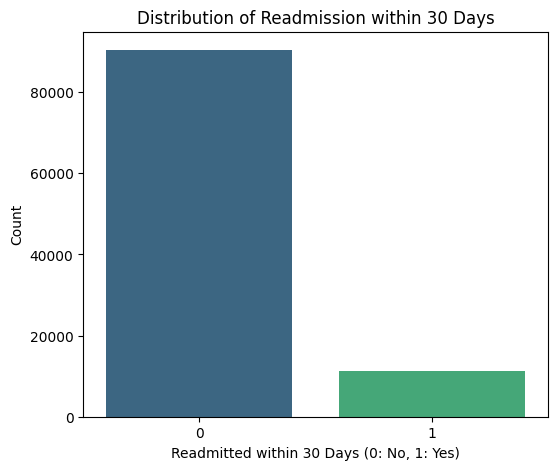

Percentage of patients readmitted within 30 days: 11.16%
Percentage of patients not readmitted within 30 days: 88.84%


In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(x='readmitted_30d', data=patient_features_df, palette='viridis')
plt.title('Distribution of Readmission within 30 Days')
plt.xlabel('Readmitted within 30 Days (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

readmission_counts = patient_features_df['readmitted_30d'].value_counts(normalize=True) * 100
print(f"Percentage of patients readmitted within 30 days: {readmission_counts[1]:.2f}%")
print(f"Percentage of patients not readmitted within 30 days: {readmission_counts[0]:.2f}%")

**Relationship between Time in Hospital and Readmission**

/tmp/ipykernel_5637/3206235409.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




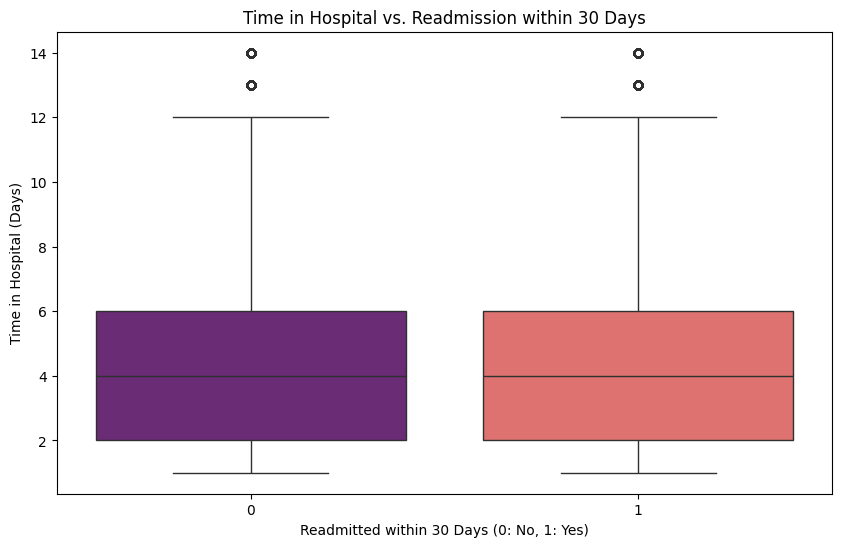

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='readmitted_30d', y='time_in_hospital', data=patient_features_df, palette='magma')
plt.title('Time in Hospital vs. Readmission within 30 Days')
plt.xlabel('Readmitted within 30 Days (0: No, 1: Yes)')
plt.ylabel('Time in Hospital (Days)')
plt.show()

**Relationship between Number of Lab Procedures and Readmission**

/tmp/ipykernel_5637/1806573553.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




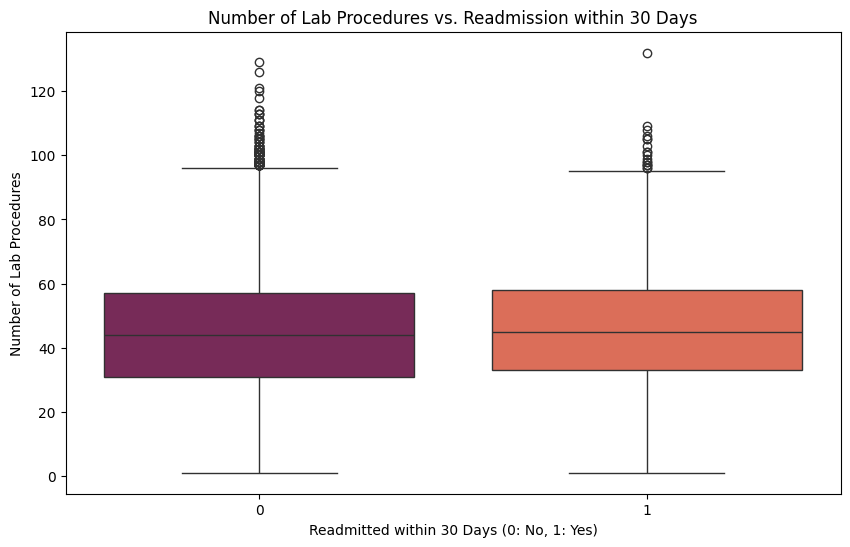

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='readmitted_30d', y='num_lab_procedures', data=patient_features_df, palette='rocket')
plt.title('Number of Lab Procedures vs. Readmission within 30 Days')
plt.xlabel('Readmitted within 30 Days (0: No, 1: Yes)')
plt.ylabel('Number of Lab Procedures')
plt.show()

**Relationship between Number of Medications and Readmission**

/tmp/ipykernel_5637/1494782878.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




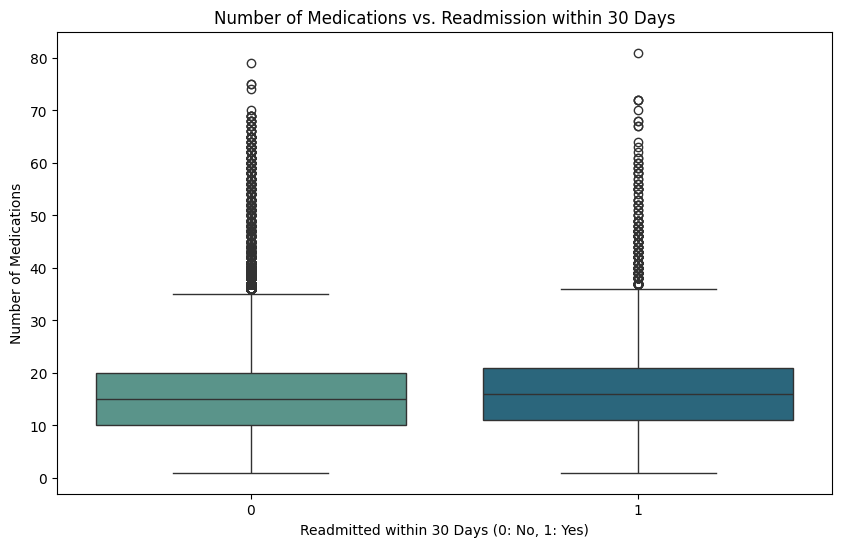

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='readmitted_30d', y='num_medications', data=patient_features_df, palette='crest')
plt.title('Number of Medications vs. Readmission within 30 Days')
plt.xlabel('Readmitted within 30 Days (0: No, 1: Yes)')
plt.ylabel('Number of Medications')
plt.show()

**Relationship between Number of Emergency Visits and Readmission**

/tmp/ipykernel_5637/2118161222.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




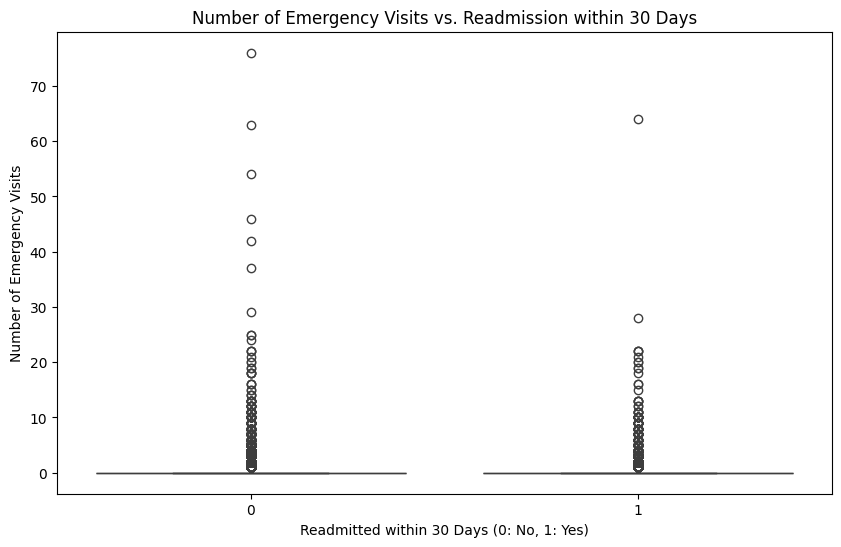

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='readmitted_30d', y='number_emergency', data=patient_features_df, palette='flare')
plt.title('Number of Emergency Visits vs. Readmission within 30 Days')
plt.xlabel('Readmitted within 30 Days (0: No, 1: Yes)')
plt.ylabel('Number of Emergency Visits')
plt.show()

# **Step 3: Train XGBoost with SHAP Explainability**

Train the classifier on the extracted SQL table and initialize the SHAP explainer to calculate local feature contributions.

In [ ]:
import shap
from sklearn.model_selection import train_test_split
import xgboost as xgb

# Query processed features
features_df = con.execute("SELECT * FROM patient_features").df()

feature_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications",
    "number_emergency",
]
X = features_df[feature_cols]
y = features_df["readmitted_30d"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train XGBoost model
model = xgb.XGBClassifier(n_estimators=100, max_depth=4, eval_metric="logloss")
model.fit(X_train, y_train)

# Initialize SHAP TreeExplainer
explainer = shap.TreeExplainer(model)
print("XGBoost and SHAP explainer successfully initialized.")

XGBoost and SHAP explainer successfully initialized.


**Calculate SHAP Values and Generate Summary Plot**

This plot shows the importance of each feature. Features are ordered by their impact on the model's output. The color represents the feature value (red for high, blue for low), and the horizontal location shows whether the effect of that value is associated with a higher or lower prediction.

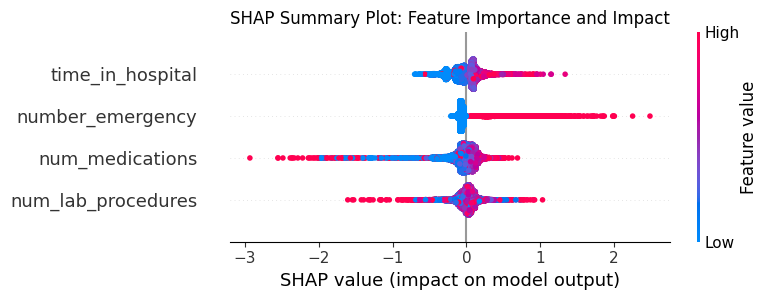

SHAP values calculated and summary plot generated.


In [ ]:
# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Generate SHAP summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot: Feature Importance and Impact')
plt.tight_layout()
plt.show()

print("SHAP values calculated and summary plot generated.")

**Key Observations from this plot:**

**time_in_hospital:** Appears to be one of the most influential features. Higher time_in_hospital values (red dots) generally correlate with higher SHAP values, suggesting that longer hospital stays increase the predicted probability of readmission. Conversely, shorter stays (blue dots) tend to decrease the predicted probability.

**num_medications:** Also shows a significant impact. Higher numbers of medications (red dots) seem to push the prediction towards readmission, while lower numbers (blue dots) push it away.

**number_emergency:** Higher numbers of emergency visits (red dots) are strongly associated with a higher predicted probability of readmission. This aligns with our earlier visualization finding.

**num_lab_procedures:** This feature seems to have a more distributed impact, with both high and low values influencing predictions in various ways, but its overall impact appears less concentrated than time_in_hospital or number_emergency.

In summary, the SHAP plot confirms that features like time_in_hospital, num_medications, and especially number_emergency are crucial drivers in predicting patient readmission within 30 days.

**XGBoost Model Evaluation Metrics**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.8875
Precision: 0.3529
Recall: 0.0026
F1-Score: 0.0052


**Accuracy: 0.8875 (88.75%)**

This indicates that the model correctly predicted the outcome (readmitted or not readmitted) for about 88.75% of the patients in the test set. While seemingly high, given that approximately 88.84% of patients are not readmitted, a model that simply predicts 'not readmitted' for everyone would achieve similar accuracy. This suggests that accuracy alone is misleading for this imbalanced dataset.

**Precision: 0.3529 (35.29%)**

Of all the patients the model predicted would be readmitted, about 35.29% actually were. This means a significant number of patients predicted as 'at-risk' by the model were actually false positives.

**Recall: 0.0026 (0.26%)**

This is a very low recall score. It means the model only correctly identified a tiny fraction (0.26%) of all patients who were actually readmitted. In a healthcare context, this is a critical issue as the model is missing almost all truly at-risk patients, making it ineffective for identifying readmission cases.

**F1-Score: 0.0052 (0.52%)**

The F1-score is the harmonic mean of precision and recall. A very low F1-score like this confirms that the model's overall performance is poor, especially in its ability to balance precision and recall for the minority class (readmitted patients).

**Conclusion:**

The model, in its current state, is largely failing to identify patients who will be readmitted within 30 days. Despite a high overall accuracy, its extremely low recall indicates that it's not useful for its intended purpose of flagging high-risk patients. This is likely due to the highly imbalanced nature of the target variable.

**ROC Curve and AUC**

To further evaluate the model's performance, especially considering the class imbalance, let's plot the Receiver Operating Characteristic (ROC) curve and calculate the Area Under the Curve (AUC). The ROC curve illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The AUC provides an aggregate measure of performance across all possible classification thresholds.

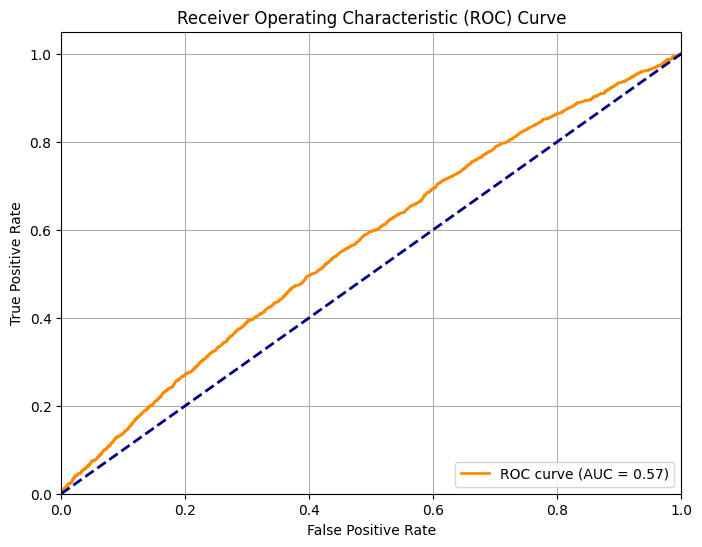

Area Under the Curve (AUC): 0.5666


In [ ]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class
y_proba = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve metrics
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Area Under the Curve (AUC): {roc_auc:.4f}")

An **AUC of 0.5666** suggests that the model has a limited ability to distinguish between the positive and negative classes (readmitted vs. not readmitted). An AUC of 0.5 indicates a model that performs no better than random chance, while an AUC of 1.0 represents a perfect classifier. This result further confirms the challenges noted earlier with the model's low recall, likely due to the imbalanced nature of the dataset. This score indicates there is significant room for improvement, possibly through feature engineering, hyperparameter tuning, or using techniques specifically designed for imbalanced classification.

**Confusion Matrix**

A confusion matrix provides a detailed breakdown of the model's classification results, showing the counts of true positives, true negatives, false positives, and false negatives. This is particularly useful for imbalanced datasets, as it helps us understand where the model is succeeding and failing beyond simple accuracy metrics.

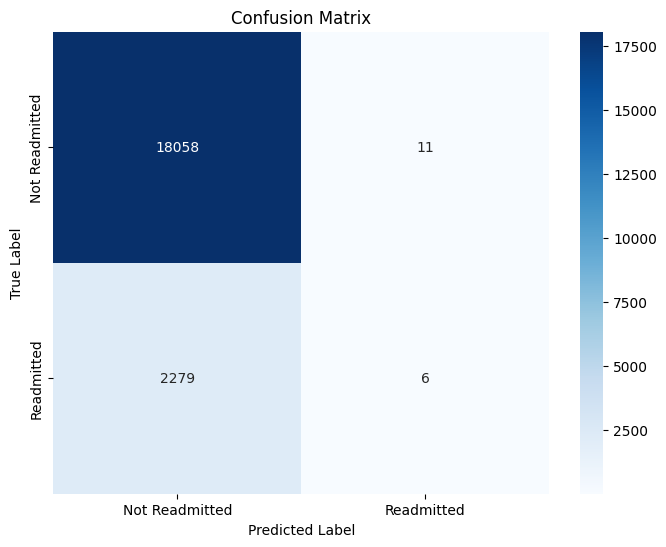

True Negatives (TN): 18058
False Positives (FP): 11
False Negatives (FN): 2279
True Positives (TP): 6


In [ ]:
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print(f"True Negatives (TN): {cm[0, 0]}")
print(f"False Positives (FP): {cm[0, 1]}")
print(f"False Negatives (FN): {cm[1, 0]}")
print(f"True Positives (TP): {cm[1, 1]}")

# **Step 4: Build the 3-Agent Workflow (Groq Compound)**

Define the agent stack using Groq's groq/compound system for Agent 3.

In [ ]:
import json
import os
from google.colab import userdata
from groq import Groq

# Initialize Groq client with your API key
# Ensure you have stored your Groq API key in Colab's secret manager under the name 'GROQ_API_KEY'
GROQ_API_KEY = userdata.get('GROQ_API_KEY')
groq_client = Groq(api_key=GROQ_API_KEY)


# --- AGENT 1: SQL & Data Extractor (DuckDB) ---
def agent_sql_extractor(patient_nbr: int) -> dict:
  """Extracts structured patient vitals and encounter history using SQL."""
  query = f"""
    SELECT time_in_hospital, num_lab_procedures, num_medications, number_emergency
    FROM patient_features
    WHERE patient_nbr = {patient_nbr}
    LIMIT 1
    """
  res = con.execute(query).df()
  if res.empty:
    raise ValueError(f"No records found for patient_nbr: {patient_nbr}")
  return res.to_dict(orient="records")[0]


# --- AGENT 2: Clinical ML Predictor (XGBoost + SHAP) ---
def agent_ml_predictor(patient_data: dict) -> dict:
  """Runs inference and computes SHAP feature attributions."""
  input_df = pd.DataFrame([patient_data])
  prob = model.predict_proba(input_df)[0][1]

  # Extract local feature importance via SHAP
  shap_values = explainer.shap_values(input_df)[0]
  top_features = sorted(
      zip(input_df.columns, shap_values), key=lambda x: abs(x[1]), reverse=True
  )[:3]

  return {
      "readmission_probability": round(float(prob), 4),
      "risk_tier": "High" if prob > 0.4 else "Moderate" if prob > 0.2 else "Low",
      "top_drivers": [
          f"{feat} (impact: {val:+.3f})" for feat, val in top_features
      ],
  }


# --- AGENT 3: BI & Executive Synthesizer (Groq Compound) ---
def agent_executive_synthesizer(
    patient_id: int, vitals: dict, ml_results: dict
) -> str:
  """Generates structured clinical transition-of-care report using groq/compound."""
  system_instruction = (
      "You are an expert Clinical Business Intelligence Copilot. "
      "Your objective is to provide structured, executive-ready risk reports for hospital care teams."
  )

  user_prompt = f"""
    Analyze the following patient readmission assessment and provide an executive clinical brief:

    - Patient Identifier: {patient_id}
    - Extracted Clinical Metrics: {json.dumps(vitals)}
    - Predictive Model & SHAP Results: {json.dumps(ml_results)}

    Structure your output as follows:
    1. Executive Risk Summary (Risk Tier & Probability)
    2. Primary Contributing Drivers (Explain the impact of the top SHAP features)
    3. Targeted Transition-of-Care Interventions (Specific discharge recommendations)
    """

  chat_completion = groq_client.chat.completions.create(
      model="groq/compound",
      messages=[
          {"role": "system", "content": system_instruction},
          {"role": "user", "content": user_prompt},
      ],
  )

  return chat_completion.choices[0].message.content

In [ ]:
import json
import os
from google.colab import userdata
from groq import Groq

# Initialize Groq client with your API key from Colab secrets
# Ensure you have stored your Groq API key in Colab's secret manager under the name 'GROQ_API_KEY'
GROQ_API_KEY = userdata.get('GROQ_API_KEY')
groq_client = Groq(api_key=GROQ_API_KEY)


# --- AGENT 1: SQL & Data Extractor (DuckDB) ---
def agent_sql_extractor(patient_nbr: int) -> dict:
  """Extracts structured patient vitals and encounter history using SQL."""
  query = f"""
    SELECT time_in_hospital, num_lab_procedures, num_medications, number_emergency
    FROM patient_features
    WHERE patient_nbr = {patient_nbr}
    LIMIT 1
    """
  res = con.execute(query).df()
  if res.empty:
    raise ValueError(f"No records found for patient_nbr: {patient_nbr}")
  return res.to_dict(orient="records")[0]


# --- AGENT 2: Clinical ML Predictor (XGBoost + SHAP) ---
def agent_ml_predictor(patient_data: dict) -> dict:
  """Runs inference and computes SHAP feature attributions."""
  input_df = pd.DataFrame([patient_data])
  prob = model.predict_proba(input_df)[0][1]

  # Extract local feature importance via SHAP
  shap_values = explainer.shap_values(input_df)[0]
  top_features = sorted(
      zip(input_df.columns, shap_values), key=lambda x: abs(x[1]), reverse=True
  )[:3]

  return {
      "readmission_probability": round(float(prob), 4),
      "risk_tier": "High" if prob > 0.4 else "Moderate" if prob > 0.2 else "Low",
      "top_drivers": [
          f"{feat} (impact: {val:+.3f})" for feat, val in top_features
      ],
  }


# --- AGENT 3: BI & Executive Synthesizer (Groq Compound) ---
def agent_executive_synthesizer(
    patient_id: int, vitals: dict, ml_results: dict
) -> str:
  """Generates structured clinical transition-of-care report using groq/compound."""
  system_instruction = (
      "You are an expert Clinical Business Intelligence Copilot. "
      "Your objective is to provide structured, executive-ready risk reports for hospital care teams."
  )

  user_prompt = f"""
    Analyze the following patient readmission assessment and provide an executive clinical brief:

    - Patient Identifier: {patient_id}
    - Extracted Clinical Metrics: {json.dumps(vitals)}
    - Predictive Model & SHAP Results: {json.dumps(ml_results)}

    Structure your output as follows:
    1. Executive Risk Summary (Risk Tier & Probability)
    2. Primary Contributing Drivers (Explain the impact of the top SHAP features)
    3. Targeted Transition-of-Care Interventions (Specific discharge recommendations)
    """

  chat_completion = groq_client.chat.completions.create(
      model="groq/compound",
      messages=[
          {"role": "system", "content": system_instruction},
          {"role": "user", "content": user_prompt},
      ],
  )

  return chat_completion.choices[0].message.content

#### **Note on API Key Security:**

For enhanced security and best practices, it's recommended to store your API keys as secrets in Google Colab. You can access the secrets manager by clicking the "🔑" icon in the left-hand panel of your Colab notebook. Store your Groq API key with the name `GROQ_API_KEY`.

In [ ]:
sample_patient_nbr = 8222157

# Agent 1: SQL & Data Extractor
vitals = agent_sql_extractor(sample_patient_nbr)
print(f"Extracted Vitals for Patient {sample_patient_nbr}: {vitals}")

# Agent 2: Clinical ML Predictor
ml_results = agent_ml_predictor(vitals)
print(f"ML Prediction Results for Patient {sample_patient_nbr}: {ml_results}")

# Agent 3: BI & Executive Synthesizer
executive_brief = agent_executive_synthesizer(sample_patient_nbr, vitals, ml_results)
print(f"\nExecutive Clinical Brief for Patient {sample_patient_nbr}:\n{executive_brief}")

Extracted Vitals for Patient 8222157: {'time_in_hospital': 1, 'num_lab_procedures': 41, 'num_medications': 1, 'number_emergency': 0}
ML Prediction Results for Patient 8222157: {'readmission_probability': 0.0107, 'risk_tier': 'Low', 'top_drivers': ['num_medications (impact: -1.808)', 'time_in_hospital (impact: -0.293)', 'num_lab_procedures (impact: -0.252)']}

Executive Clinical Brief for Patient 8222157:
**Executive Clinical Brief – Patient 8222157**

---

### 1. Executive Risk Summary  
- **Risk Tier:** **Low**  
- **Readmission Probability:** **0.0107** (≈ 1 % chance of readmission within the target window)  

The model places this patient firmly in the low‑risk category, indicating that, based on the available variables, the likelihood of an unplanned return to the hospital is minimal.

---

### 2. Primary Contributing Drivers (SHAP Interpretation)

| SHAP Feature | Impact (Δ log‑odds) | Clinical Interpretation |
|--------------|--------------------|--------------------------|
| **n

**To improve the performance of Agent 2, we would need to employ strategies like:**

**Addressing Class Imbalance:** Techniques such as oversampling the minority class, undersampling the majority class, or using scale_pos_weight in XGBoost.

**Adjusting the Classification Threshold:** The default threshold of 0.5 might be too high for the minority class.

**Optimizing for different metrics:** Focusing on metrics like Recall or F1-Score during model training and evaluation, rather than just accuracy.

### Improving Agent 2: Retraining XGBoost with `scale_pos_weight`

To address the severe class imbalance (only ~11% readmitted patients), we will retrain the XGBoost model using the `scale_pos_weight` parameter. This parameter is used to balance the positive and negative weights, which can help the model focus more on correctly classifying the minority class (readmitted patients) without being overwhelmed by the majority class. A higher `scale_pos_weight` value increases the cost of misclassifying the positive class, leading to improved recall for the minority class.

In [ ]:
# Calculate scale_pos_weight for XGBoost to handle class imbalance
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight = neg_count / pos_count

print(f"Count of non-readmitted patients (negative class): {neg_count}")
print(f"Count of readmitted patients (positive class): {pos_count}")
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

Count of non-readmitted patients (negative class): 72340
Count of readmitted patients (positive class): 9072
Calculated scale_pos_weight: 7.97


In [ ]:
import xgboost as xgb

# Retrain XGBoost model with scale_pos_weight
# This parameter helps balance the positive and negative weights, addressing class imbalance.
model_improved = xgb.XGBClassifier(n_estimators=100, max_depth=4, eval_metric="logloss", scale_pos_weight=scale_pos_weight, random_state=42)
model_improved.fit(X_train, y_train)

# Initialize SHAP TreeExplainer for the improved model
explainer_improved = shap.TreeExplainer(model_improved)

print("Improved XGBoost model and SHAP explainer successfully initialized.")

Improved XGBoost model and SHAP explainer successfully initialized.


**Model Metrics after First Improvement (Class Imbalance)**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\n--- Evaluation for Improved XGBoost Model ---")

# Make predictions on the test set with the improved model
y_pred_improved = model_improved.predict(X_test)

# Calculate evaluation metrics for the improved model
accuracy_improved = accuracy_score(y_test, y_pred_improved)
precision_improved = precision_score(y_test, y_pred_improved)
recall_improved = recall_score(y_test, y_pred_improved)
f1_improved = f1_score(y_test, y_pred_improved)

print(f"Accuracy (Improved): {accuracy_improved:.4f}")
print(f"Precision (Improved): {precision_improved:.4f}")
print(f"Recall (Improved): {recall_improved:.4f}")
print(f"F1-Score (Improved): {f1_improved:.4f}")


--- Evaluation for Improved XGBoost Model ---
Accuracy (Improved): 0.5749
Precision (Improved): 0.1334
Recall (Improved): 0.5072
F1-Score (Improved): 0.2113


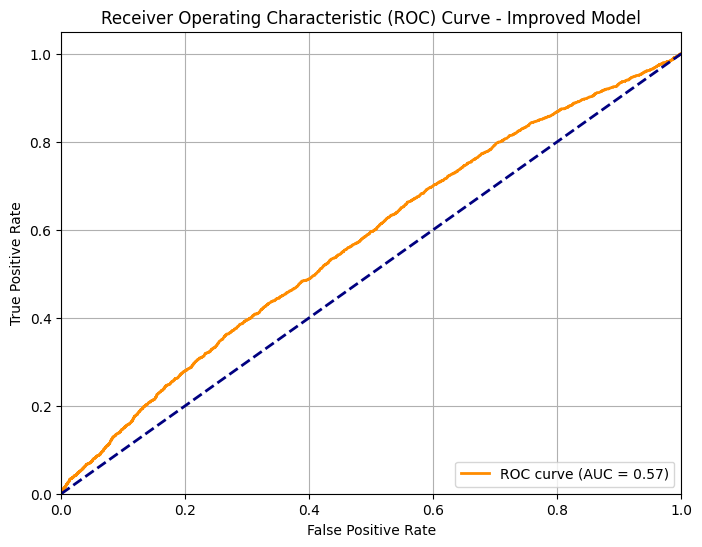

Area Under the Curve (AUC) (Improved): 0.5712


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class from the improved model
y_proba_improved = model_improved.predict_proba(X_test)[:, 1]

# Calculate ROC curve metrics for the improved model
fpr_improved, tpr_improved, thresholds_improved = roc_curve(y_test, y_proba_improved)
roc_auc_improved = auc(fpr_improved, tpr_improved)

# Plot the ROC curve for the improved model
plt.figure(figsize=(8, 6))
plt.plot(fpr_improved, tpr_improved, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_improved:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Improved Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Area Under the Curve (AUC) (Improved): {roc_auc_improved:.4f}")

**A slight Improvment is noticed in AUC**

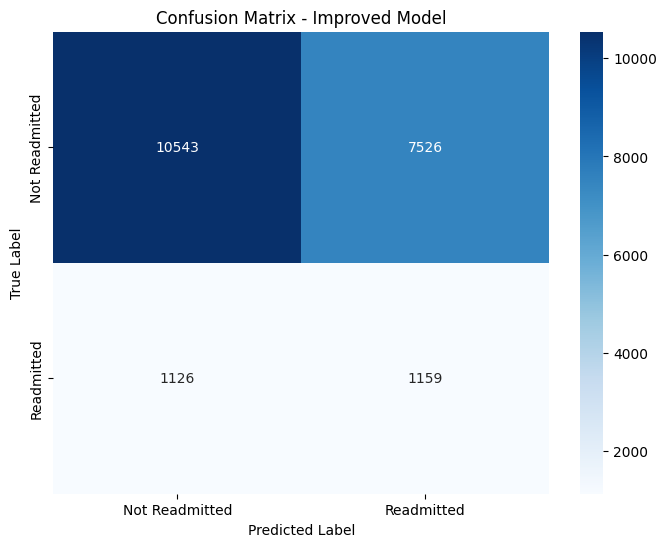

True Negatives (TN) (Improved): 10543
False Positives (FP) (Improved): 7526
False Negatives (FN) (Improved): 1126
True Positives (TP) (Improved): 1159


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate the confusion matrix for the improved model
cm_improved = confusion_matrix(y_test, y_pred_improved)

# Plot the confusion matrix for the improved model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Improved Model')
plt.show()

print(f"True Negatives (TN) (Improved): {cm_improved[0, 0]}")
print(f"False Positives (FP) (Improved): {cm_improved[0, 1]}")
print(f"False Negatives (FN) (Improved): {cm_improved[1, 0]}")
print(f"True Positives (TP) (Improved): {cm_improved[1, 1]}")

### Updating `agent_ml_predictor` to use the Improved Model

Now that we have an improved model, we need to update the `agent_ml_predictor` function to use `model_improved` and `explainer_improved` for predictions and SHAP value calculations. This ensures that the entire 3-agent workflow benefits from the enhanced predictive capabilities.

In [ ]:
# Update Agent 2 to use the improved model and explainer
# --- AGENT 2: Clinical ML Predictor (XGBoost + SHAP) ---
def agent_ml_predictor_improved(patient_data: dict) -> dict:
  """Runs inference and computes SHAP feature attributions using the improved model."""
  input_df = pd.DataFrame([patient_data])
  prob = model_improved.predict_proba(input_df)[0][1]

  # Extract local feature importance via SHAP
  # Ensure explainer_improved is used here
  shap_values = explainer_improved.shap_values(input_df)[0]
  top_features = sorted(
      zip(input_df.columns, shap_values), key=lambda x: abs(x[1]), reverse=True
  )[:3]

  return {
      "readmission_probability": round(float(prob), 4),
      "risk_tier": "High" if prob > 0.4 else "Moderate" if prob > 0.2 else "Low",
      "top_drivers": [
          f"{feat} (impact: {val:+.3f})" for feat, val in top_features
      ],
  }

We have created a new function `agent_ml_predictor_improved` that utilizes the retrained model. Now, let's test the entire 3-agent workflow again, replacing the original `agent_ml_predictor` with `agent_ml_predictor_improved`.

In [ ]:
sample_patient_nbr = 8222157

# Agent 1: SQL & Data Extractor
vitals = agent_sql_extractor(sample_patient_nbr)
print(f"Extracted Vitals for Patient {sample_patient_nbr}: {vitals}")

# Agent 2: Clinical ML Predictor (Using the IMPROVED model)
ml_results_improved = agent_ml_predictor_improved(vitals)
print(f"ML Prediction Results for Patient {sample_patient_nbr} (Improved Model): {ml_results_improved}")

# Agent 3: BI & Executive Synthesizer
executive_brief_improved = agent_executive_synthesizer(sample_patient_nbr, vitals, ml_results_improved)
print(f"\nExecutive Clinical Brief for Patient {sample_patient_nbr} (Improved Model):\n{executive_brief_improved}")

Extracted Vitals for Patient 8222157: {'time_in_hospital': 1, 'num_lab_procedures': 41, 'num_medications': 1, 'number_emergency': 0}
ML Prediction Results for Patient 8222157 (Improved Model): {'readmission_probability': 0.034, 'risk_tier': 'Low', 'top_drivers': ['num_medications (impact: -2.806)', 'num_lab_procedures (impact: -0.511)', 'number_emergency (impact: -0.031)']}

Executive Clinical Brief for Patient 8222157 (Improved Model):
**Patient Identifier:** 8222157  

---

### 1. Executive Risk Summary (Risk Tier & Probability)  
- **Risk Tier:** Low  
- **Readmission Probability:** 3.4 %  

---

### 2. Primary Contributing Drivers (SHAP Feature Impacts)  

| SHAP Feature | Impact (Δ log‑odds) | Clinical Interpretation |
|--------------|-------------------|--------------------------|
| **num_medications** (1 medication) | **‑2.806** | A very low medication count reduces complexity and the chance of medication‑related errors or non‑adherence, strongly pulling the risk downward. |
| *

**Readmission probability improved from 0.0107% to 3.4% for the same patient. Still the performance of Agent 2 is not satisfying. That's why we are looking for the hyperparameter tuning for Agent 2**

### Hyperparameter Tuning for Agent 2: Optimizing with GridSearchCV

To further optimize the improved XGBoost model, we can perform hyperparameter tuning. This process involves searching for the best set of hyperparameters (parameters that are not learned from the data) that maximize the model's performance on a given metric.

`GridSearchCV` is a common method that systematically builds and evaluates a model for each combination of hyperparameters specified in a grid. Given our focus on improving AUC, we will use `'roc_auc'` as the scoring metric for our search.

In [ ]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Define the parameter grid to search
# We'll tune a few key parameters, including n_estimators, max_depth, and learning_rate.
# The scale_pos_weight is already determined, but could also be tuned if desired.
param_grid = {
    'n_estimators': [50, 100, 200], # Number of boosting rounds
    'max_depth': [3, 4, 5],       # Maximum depth of a tree
    'learning_rate': [0.01, 0.1, 0.2], # Step size shrinkage to prevent overfitting
    'subsample': [0.7, 0.8, 0.9], # Subsample ratio of the training instance
    'colsample_bytree': [0.7, 0.8, 0.9] # Subsample ratio of columns when constructing each tree
}

# Initialize the XGBoost classifier with the calculated scale_pos_weight
# We pass scale_pos_weight to ensure it's considered during tuning.
base_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight, # Use the previously calculated scale_pos_weight
    random_state=42
)

# Initialize GridSearchCV
# We use 'roc_auc' as the scoring metric, given the previous focus on AUC improvement
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3, # 3-fold cross-validation
    verbose=1,
    n_jobs=-1 # Use all available cores
)

print("Starting GridSearchCV to find optimal hyperparameters...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV complete.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best ROC AUC score: {grid_search.best_score_:.4f}")

Starting GridSearchCV to find optimal hyperparameters...
Fitting 3 folds for each of 243 candidates, totalling 729 fits
GridSearchCV complete.
Best parameters found: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Best ROC AUC score: 0.5795


### Re-training the Model with Best Parameters and Re-evaluating

After finding the best hyperparameters, we will train a new model using these parameters. Then, we will re-evaluate its performance and update the `agent_ml_predictor_improved` function to use this newly optimized model.

In [ ]:
# Train a new XGBoost model with the best parameters found by GridSearchCV
model_optimized = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight, # Keep the same scale_pos_weight
    random_state=42,
    **grid_search.best_params_
)
model_optimized.fit(X_train, y_train)

# Initialize SHAP TreeExplainer for the optimized model
explainer_optimized = shap.TreeExplainer(model_optimized)

print("Optimized XGBoost model and SHAP explainer successfully initialized.")

Optimized XGBoost model and SHAP explainer successfully initialized.



--- Evaluation for Optimized XGBoost Model ---
Accuracy (Optimized): 0.5552
Precision (Optimized): 0.1339
Recall (Optimized): 0.5418
F1-Score (Optimized): 0.2147
Area Under the Curve (AUC) (Optimized): 0.5748


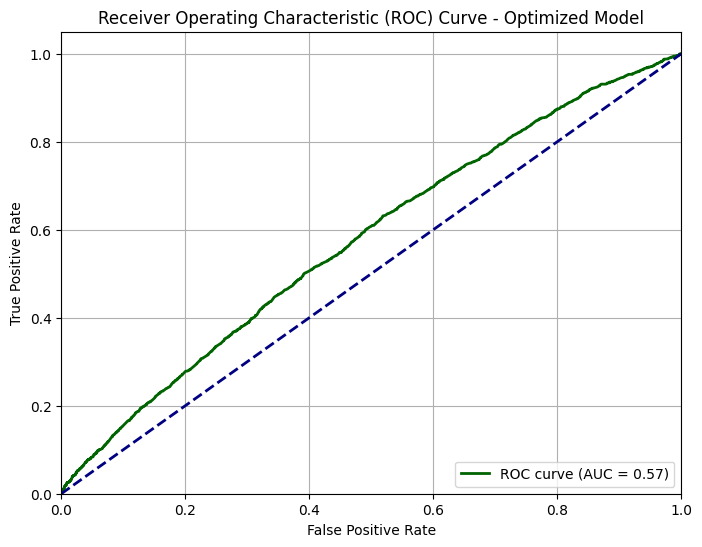

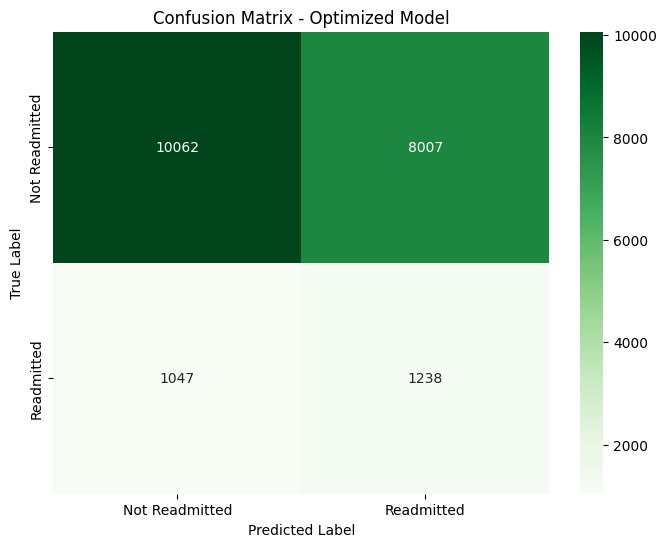

True Negatives (TN) (Optimized): 10062
False Positives (FP) (Optimized): 8007
False Negatives (FN) (Optimized): 1047
True Positives (TP) (Optimized): 1238


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Evaluation for Optimized XGBoost Model ---")

# Make predictions on the test set with the optimized model
y_pred_optimized = model_optimized.predict(X_test)
y_proba_optimized = model_optimized.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics for the optimized model
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
precision_optimized = precision_score(y_test, y_pred_optimized)
recall_optimized = recall_score(y_test, y_pred_optimized)
f1_optimized = f1_score(y_test, y_pred_optimized)
fpr_optimized, tpr_optimized, _ = roc_curve(y_test, y_proba_optimized)
roc_auc_optimized = auc(fpr_optimized, tpr_optimized)
cm_optimized = confusion_matrix(y_test, y_pred_optimized)

print(f"Accuracy (Optimized): {accuracy_optimized:.4f}")
print(f"Precision (Optimized): {precision_optimized:.4f}")
print(f"Recall (Optimized): {recall_optimized:.4f}")
print(f"F1-Score (Optimized): {f1_optimized:.4f}")
print(f"Area Under the Curve (AUC) (Optimized): {roc_auc_optimized:.4f}")

# Plot ROC curve for the optimized model
plt.figure(figsize=(8, 6))
plt.plot(fpr_optimized, tpr_optimized, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc_optimized:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Optimized Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Plot confusion matrix for the optimized model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Readmitted', 'Readmitted'],
            yticklabels=['Not Readmitted', 'Readmitted'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Optimized Model')
plt.show()

print(f"True Negatives (TN) (Optimized): {cm_optimized[0, 0]}")
print(f"False Positives (FP) (Optimized): {cm_optimized[0, 1]}")
print(f"False Negatives (FN) (Optimized): {cm_optimized[1, 0]}")
print(f"True Positives (TP) (Optimized): {cm_optimized[1, 1]}")

So we can see, after hyperparameter tuning, Optimized Model (with scale_pos_weight and Hyperparameter Tuning):

Best Parameters found by GridSearchCV

{**'colsample_bytree': 0.8**,

**'learning_rate': 0.1**,

**'max_depth': 3**,

**'n_estimators': 50**,

**'subsample': 0.8**}

Best Cross-Validation ROC AUC score: 0.5795

Test Set Accuracy: 0.5552

Test Set Precision: 0.1339

Test Set Recall: 0.5418

Test Set F1-Score: 0.2147

**Test Set AUC: 0.5748**

**AUC Improvement:** The AUC on the test set has slightly increased again, from 0.5712 (improved model) to 0.5748 (optimized model). This indicates that hyperparameter tuning helped the model distinguish between classes a little better than just using scale_pos_weight alone.

**Recall and F1-Score:** The Recall further improved from 0.5072 to 0.5418, meaning the optimized model is even better at catching true readmission cases. The F1-Score also saw a minor increase from 0.2113 to 0.2147, showing a marginally better balance between precision and recall.

**Accuracy and Precision:** Similar to the previous improvement step, Accuracy (0.5552) and Precision (0.1339) remain lower than the original model, which is expected when prioritizing recall in an imbalanced dataset. The model is intentionally making more 'readmission' predictions to avoid missing actual cases, leading to more false positives.

### Updating `agent_ml_predictor` to use the Optimized Model

Finally, we will update the `agent_ml_predictor_improved` function (or create a new one `agent_ml_predictor_optimized`) to use the `model_optimized` and `explainer_optimized` for predictions and SHAP value calculations. This ensures that the entire 3-agent workflow benefits from the enhanced predictive capabilities resulting from hyperparameter tuning.

In [ ]:
# Update Agent 2 to handle DataFrame or Dict inputs correctly
def agent_ml_predictor_optimized(patient_data):
    """Runs inference and computes SHAP feature attributions using the optimized model."""
    # If patient_data is a DataFrame (like from fetchdf), convert to dict or ensure 2D
    if isinstance(patient_data, pd.DataFrame):
        input_df = patient_data[feature_cols].copy()
    else:
        # Ensure we have a list of dicts for the DataFrame constructor
        input_df = pd.DataFrame([patient_data])

    prob = model_optimized.predict_proba(input_df)[0][1]

    # Extract local feature importance via SHAP
    shap_values = explainer_optimized.shap_values(input_df)[0]
    top_features = sorted(
        zip(input_df.columns, shap_values), key=lambda x: abs(x[1]), reverse=True
    )[:3]

    return {
        "readmission_probability": round(float(prob), 4),
        "risk_tier": "High" if prob > 0.4 else "Moderate" if prob > 0.2 else "Low",
        "top_drivers": [
            f"{feat} (impact: {val:+.3f})" for feat, val in top_features
        ],
    }

Extracted Vitals for Patient 8222157: {'time_in_hospital': 1, 'num_lab_procedures': 41, 'num_medications': 1, 'number_emergency': 0}
ML Prediction Results for Patient 8222157 (Optimized Model): {'readmission_probability': 0.2195, 'risk_tier': 'Moderate', 'top_drivers': ['num_medications (impact: -0.828)', 'time_in_hospital (impact: -0.296)', 'number_emergency (impact: -0.075)']}

Executive Clinical Brief for Patient 8222157 (Optimized Model):
**Executive Clinical Brief – Patient 8222157**

---

### 1. Executive Risk Summary  
- **Readmission Probability:** **21.9 %** (0.2195)  
- **Risk Tier:** **Moderate**  

The model indicates a moderate likelihood that this patient will be readmitted within the standard 30‑day window.

---

### 2. Primary Contributing Drivers (SHAP Interpretation)

| SHAP Feature | Impact Value | Clinical Interpretation |
|--------------|--------------|--------------------------|
| **num_medications** (1 medication) | **‑0.828** | A very low medication count strong

**Readmission probability improved from 3.4% to 22% for the same patient.**

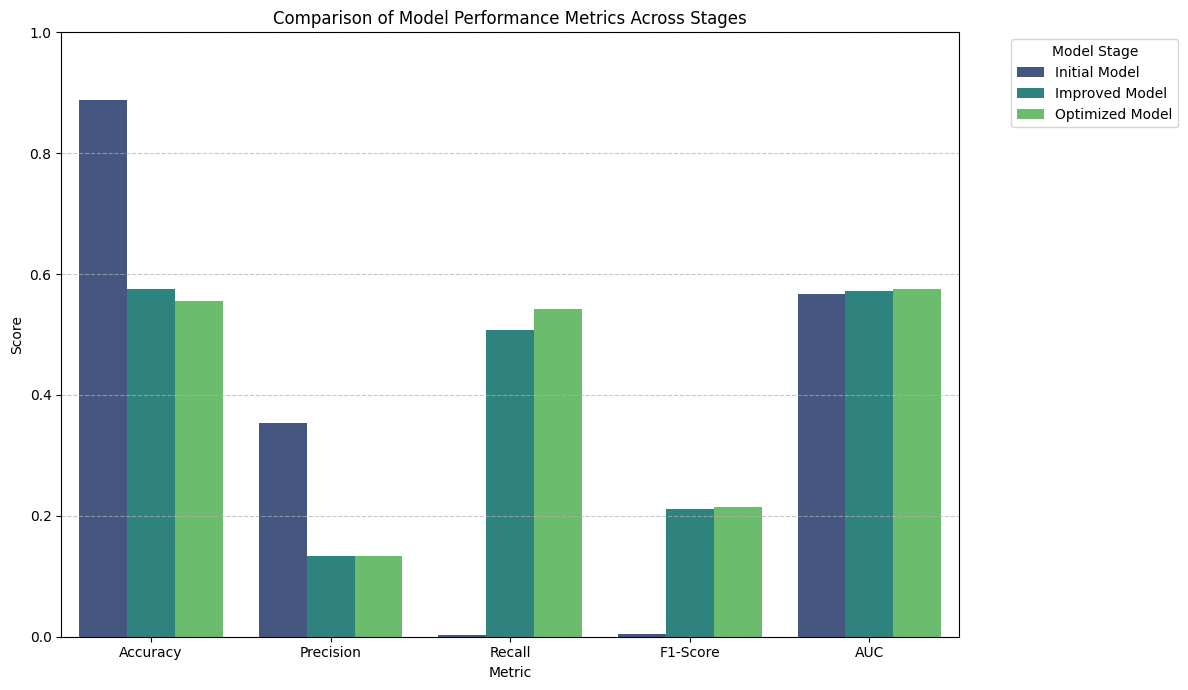

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Gather the metrics from the previous steps
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    'Initial Model': [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    'Improved Model': [
        accuracy_improved,
        precision_improved,
        recall_improved,
        f1_improved,
        roc_auc_improved
    ],
    'Optimized Model': [
        accuracy_optimized,
        precision_optimized,
        recall_optimized,
        f1_optimized,
        roc_auc_optimized
    ]
}

# Create a DataFrame
metrics_df = pd.DataFrame(metrics_data)

# Melt the DataFrame for easier plotting with seaborn
metrics_melted = metrics_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

# Create the grouped bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_melted, palette='viridis')
plt.title('Comparison of Model Performance Metrics Across Stages')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.legend(title='Model Stage', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

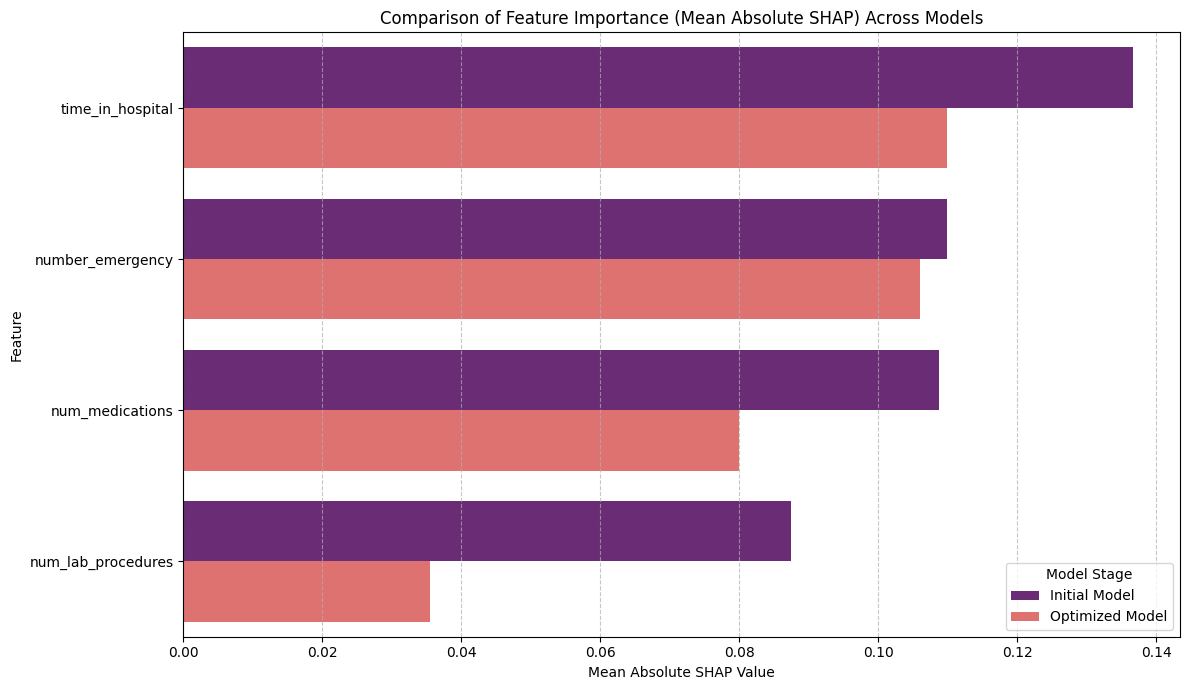

Feature importance comparison plot generated.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate SHAP values for the initial model (already done, but re-calculating for consistency and to ensure access to 'shap_values')
shap_values_initial = explainer.shap_values(X_test)

# Calculate SHAP values for the optimized model
shap_values_optimized = explainer_optimized.shap_values(X_test)

# Calculate mean absolute SHAP values for both models
mean_abs_shap_initial = np.abs(shap_values_initial).mean(axis=0)
mean_abs_shap_optimized = np.abs(shap_values_optimized).mean(axis=0)

# Create DataFrames for plotting
feature_importance_initial_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': mean_abs_shap_initial,
    'Model': 'Initial Model'
})

feature_importance_optimized_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': mean_abs_shap_optimized,
    'Model': 'Optimized Model'
})

# Combine DataFrames
combined_feature_importance_df = pd.concat([feature_importance_initial_df, feature_importance_optimized_df])

# Sort by importance from the optimized model for better visualization
order = feature_importance_optimized_df.sort_values(by='Importance', ascending=False)['Feature'].tolist()

# Create the grouped bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', hue='Model', data=combined_feature_importance_df, palette='magma', order=order)
plt.title('Comparison of Feature Importance (Mean Absolute SHAP) Across Models')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.legend(title='Model Stage')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Feature importance comparison plot generated.")

# **What we can do in future**

1. Refine Agent 3's Clinical Brief:

We can further tailor Agent 3's output to specific hospital protocols, integrate it with EHR systems, or add more dynamic intervention suggestions based on the patient's individual profile and local resources. For example, ensuring the interventions are directly mappable to standard care pathways.

2. Expand Feature Set:

Explore additional features from the raw dataset (e.g., specific diagnoses, procedures, medications, demographics) to potentially improve model performance further. This would involve more extensive feature engineering.

3. External Validation:

Test the optimized model on an entirely new, unseen dataset from a different hospital or time period to ensure generalizability and robustness.


4. Threshold Optimization:

While we've optimized for AUC during tuning, we could also explicitly optimize the classification threshold for the improved/optimized model based on the desired balance between precision and recall for the clinical context (e.g., prioritizing very high recall even if it means more false positives, to ensure no patient is missed).


5. Longitudinal Data Analysis:

If available, incorporate time-series data or patient history beyond a single admission to capture trends and chronic conditions more effectively.


6. User Interface Development:

Consider how this 3-agent system would integrate into a clinician's workflow via a user-friendly interface or dashboard, allowing for easy input of patient IDs and retrieval of AI-generated insights.


7. Cost-Benefit Analysis:

Perform a detailed analysis of the cost savings and patient outcome improvements that could result from deploying this system in a real-world clinical setting.

### Further Tailoring Agent 3: Enhancing the Clinical Brief with Specific Protocols and Dynamic Interventions

To make Agent 3's output even more valuable, we can refine its system and user prompts to include specific hospital guidelines and prompt for more dynamic, actionable interventions.

Let's define `agent_executive_synthesizer_v2` with an expanded prompt.

In [ ]:
import json
from groq import Groq

# Assuming groq_client is already initialized
# groq_client = Groq(api_key=GROQ_API_KEY)

def agent_executive_synthesizer_v2(
    patient_id: int, vitals: dict, ml_results: dict, hospital_protocols: str = ""
) -> str:
  """Generates structured clinical transition-of-care report with enhanced customization."""
  system_instruction = (
      "You are an expert Clinical Business Intelligence Copilot. "
      "Your objective is to provide structured, executive-ready risk reports for hospital care teams. "
      "Focus on actionable, evidence-based recommendations following best practices. "
  )

  # Add hospital-specific protocols to the system instruction if provided
  if hospital_protocols:
      system_instruction += f"Adhere strictly to the following hospital protocols: {hospital_protocols}"

  user_prompt = f"""
    Analyze the following patient readmission assessment and provide an executive clinical brief.
    Ensure the brief is concise, actionable, and patient-centered. Pay special attention to the risk tier
    and primary drivers when suggesting interventions.

    - Patient Identifier: {patient_id}
    - Extracted Clinical Metrics: {json.dumps(vitals)}
    - Predictive Model & SHAP Results: {json.dumps(ml_results)}

    Structure your output as follows:
    1. Executive Risk Summary (State the Risk Tier and Probability clearly)
    2. Primary Contributing Drivers (Explain the impact of the top SHAP features in clinical terms, linking to risk)
    3. Targeted Transition-of-Care Interventions (Provide 3-5 *specific and actionable* recommendations, categorized by area e.g., Medication Management, Follow-up, Education, Social Support. Ensure these are dynamic based on the patient's individual risk factors.)
    4. Bottom Line (A succinct summary statement for clinical leadership.)
    """

  chat_completion = groq_client.chat.completions.create(
      model="groq/compound", # Or another suitable Groq model
      messages=[
          {"role": "system", "content": system_instruction},
          {"role": "user", "content": user_prompt},
      ],
  )

  return chat_completion.choices[0].message.content

print("New agent_executive_synthesizer_v2 function defined.")

New agent_executive_synthesizer_v2 function defined.


Now, let's run the 3-agent workflow using `agent_executive_synthesizer_v2`.

We can also pass a hypothetical `hospital_protocols` string to demonstrate how to enforce specific guidelines.

In [ ]:
sample_patient_nbr = 8222157

# Define hypothetical hospital protocols
hospital_specific_protocols = (
    "All moderate-to-high risk patients must have a social worker consultation "
    "and a telehealth follow-up scheduled within 72 hours of discharge. "
    "Medication reconciliation must be completed by a pharmacist."
)

# Agent 1: SQL & Data Extractor
vitals_opt_v2 = agent_sql_extractor(sample_patient_nbr)
print(f"Extracted Vitals for Patient {sample_patient_nbr}: {vitals_opt_v2}")

# Agent 2: Clinical ML Predictor (Using the OPTIMIZED model)
# This remains the same as our best performing ML agent
ml_results_optimized_v2 = agent_ml_predictor_optimized(vitals_opt_v2)
print(f"ML Prediction Results for Patient {sample_patient_nbr} (Optimized Model): {ml_results_optimized_v2}")

# Agent 3: BI & Executive Synthesizer (Using the NEW, tailored version)
executive_brief_tailored = agent_executive_synthesizer_v2(
    sample_patient_nbr, vitals_opt_v2, ml_results_optimized_v2,
    hospital_protocols=hospital_specific_protocols
)
print(f"""
Executive Clinical Brief for Patient {sample_patient_nbr} (Tailored Model):
{executive_brief_tailored}
""")

Extracted Vitals for Patient 8222157: {'time_in_hospital': 1, 'num_lab_procedures': 41, 'num_medications': 1, 'number_emergency': 0}
ML Prediction Results for Patient 8222157 (Optimized Model): {'readmission_probability': 0.2195, 'risk_tier': 'Moderate', 'top_drivers': ['num_medications (impact: -0.828)', 'time_in_hospital (impact: -0.296)', 'number_emergency (impact: -0.075)']}

Executive Clinical Brief for Patient 8222157 (Tailored Model):
**Executive Clinical Brief – Patient 8222157**

---

### 1. Executive Risk Summary  
- **Risk Tier:** **Moderate**  
- **Readmission Probability:** **21.9 %**

---

### 2. Primary Contributing Drivers  

| SHAP Driver | Model Impact | Clinical Interpretation |
|-------------|--------------|--------------------------|
| **num_medications (‑0.828)** | Large negative impact | The patient is on **only one medication**, which simplifies the regimen and reduces medication‑related confusion or adverse events – a protective factor. |
| **time_in_hospital (

In [ ]:
sample_patient_nbr = 31693671

# Define hypothetical hospital protocols
hospital_specific_protocols = (
    "All moderate-to-high risk patients must have a social worker consultation "
    "and a telehealth follow-up scheduled within 72 hours of discharge. "
    "Medication reconciliation must be completed by a pharmacist."
)

# Agent 1: SQL & Data Extractor
vitals_opt_v2 = agent_sql_extractor(sample_patient_nbr)
print(f"Extracted Vitals for Patient {sample_patient_nbr}: {vitals_opt_v2}")

# Agent 2: Clinical ML Predictor (Using the OPTIMIZED model)
# This remains the same as our best performing ML agent
ml_results_optimized_v2 = agent_ml_predictor_optimized(vitals_opt_v2)
print(f"ML Prediction Results for Patient {sample_patient_nbr} (Optimized Model): {ml_results_optimized_v2}")

# Agent 3: BI & Executive Synthesizer (Using the NEW, tailored version)
executive_brief_tailored = agent_executive_synthesizer_v2(
    sample_patient_nbr, vitals_opt_v2, ml_results_optimized_v2,
    hospital_protocols=hospital_specific_protocols
)
print(f"""
Executive Clinical Brief for Patient {sample_patient_nbr} (Tailored Model):
{executive_brief_tailored}
""")

Extracted Vitals for Patient 31693671: {'time_in_hospital': 6, 'num_lab_procedures': 59, 'num_medications': 19, 'number_emergency': 0}
ML Prediction Results for Patient 31693671 (Optimized Model): {'readmission_probability': 0.5441, 'risk_tier': 'High', 'top_drivers': ['time_in_hospital (impact: +0.105)', 'num_medications (impact: +0.096)', 'number_emergency (impact: -0.062)']}

Executive Clinical Brief for Patient 31693671 (Tailored Model):
**Executive Clinical Brief – Patient 31693671**

---

### 1. Executive Risk Summary  
- **Risk Tier:** **High**  
- **Readmission Probability:** **0.5441** (≈ 54 %)  

---

### 2. Primary Contributing Drivers  
| SHAP Driver | Model Impact | Clinical Interpretation |
|-------------|--------------|--------------------------|
| **Time in Hospital (6 days)** | +0.105 | Prolonged stay often reflects severe illness, procedural complications, or deconditioning – all of which increase vulnerability to early readmission. |
| **Number of Medications (19)** 

In [ ]:
sample_patient_nbr = 107389323

# Define hypothetical hospital protocols
hospital_specific_protocols = (
    "All moderate-to-high risk patients must have a social worker consultation "
    "and a telehealth follow-up scheduled within 72 hours of discharge. "
    "Medication reconciliation must be completed by a pharmacist."
)

# Agent 1: SQL & Data Extractor
vitals_opt_v2 = agent_sql_extractor(sample_patient_nbr)
print(f"Extracted Vitals for Patient {sample_patient_nbr}: {vitals_opt_v2}")

# Agent 2: Clinical ML Predictor (Using the OPTIMIZED model)
# This remains the same as our best performing ML agent
ml_results_optimized_v2 = agent_ml_predictor_optimized(vitals_opt_v2)
print(f"ML Prediction Results for Patient {sample_patient_nbr} (Optimized Model): {ml_results_optimized_v2}")

# Agent 3: BI & Executive Synthesizer (Using the NEW, tailored version)
executive_brief_tailored = agent_executive_synthesizer_v2(
    sample_patient_nbr, vitals_opt_v2, ml_results_optimized_v2,
    hospital_protocols=hospital_specific_protocols
)
print(f"""
Executive Clinical Brief for Patient {sample_patient_nbr} (Tailored Model):
{executive_brief_tailored}
""")

Extracted Vitals for Patient 107389323: {'time_in_hospital': 5, 'num_lab_procedures': 35, 'num_medications': 23, 'number_emergency': 0}
ML Prediction Results for Patient 107389323 (Optimized Model): {'readmission_probability': 0.5158, 'risk_tier': 'High', 'top_drivers': ['num_medications (impact: +0.073)', 'time_in_hospital (impact: +0.071)', 'number_emergency (impact: -0.066)']}

Executive Clinical Brief for Patient 107389323 (Tailored Model):
**Executive Clinical Brief – Patient 107389323**

---

### 1. Executive Risk Summary  
- **Risk Tier:** **High**  
- **Readmission Probability:** **51.6 %**  

---

### 2. Primary Contributing Drivers  
| SHAP Driver | Model Impact | Clinical Interpretation |
|-------------|--------------|--------------------------|
| **Number of Medications (23)** | **+0.073** | Polypharmacy raises the chance of drug‑drug interactions, dosing errors, and non‑adherence, all of which are strong predictors of early readmission. |
| **Time in Hospital (5 days)** | 

In [ ]:
sample_patient_nbr = 84488562

# Define hypothetical hospital protocols
hospital_specific_protocols = (
    "All moderate-to-high risk patients must have a social worker consultation "
    "and a telehealth follow-up scheduled within 72 hours of discharge. "
    "Medication reconciliation must be completed by a pharmacist."
)

# Agent 1: SQL & Data Extractor
vitals_opt_v2 = agent_sql_extractor(sample_patient_nbr)
print(f"Extracted Vitals for Patient {sample_patient_nbr}: {vitals_opt_v2}")

# Agent 2: Clinical ML Predictor (Using the OPTIMIZED model)
# This remains the same as our best performing ML agent
ml_results_optimized_v2 = agent_ml_predictor_optimized(vitals_opt_v2)
print(f"ML Prediction Results for Patient {sample_patient_nbr} (Optimized Model): {ml_results_optimized_v2}")

# Agent 3: BI & Executive Synthesizer (Using the NEW, tailored version)
executive_brief_tailored = agent_executive_synthesizer_v2(
    sample_patient_nbr, vitals_opt_v2, ml_results_optimized_v2,
    hospital_protocols=hospital_specific_protocols
)
print(f"""
Executive Clinical Brief for Patient {sample_patient_nbr} (Tailored Model):
{executive_brief_tailored}
""")

Extracted Vitals for Patient 84488562: {'time_in_hospital': 2, 'num_lab_procedures': 53, 'num_medications': 6, 'number_emergency': 0}
ML Prediction Results for Patient 84488562 (Optimized Model): {'readmission_probability': 0.4076, 'risk_tier': 'High', 'top_drivers': ['num_medications (impact: -0.201)', 'time_in_hospital (impact: -0.095)', 'number_emergency (impact: -0.076)']}

Executive Clinical Brief for Patient 84488562 (Tailored Model):
**Executive Clinical Brief – Patient 84488562**

---

### 1. Executive Risk Summary  
- **Risk Tier:** **High**  
- **Readmission Probability:** **40.8 %**  

---

### 2. Primary Contributing Drivers  

| SHAP Driver | Model Impact | Clinical Interpretation & Link to Readmission Risk |
|-------------|--------------|------------------------------------------------------|
| **Number of medications (6)** | **‑0.201** (largest negative contribution) | A poly‑pharmacy profile increases the chance of dosing errors, non‑adherence, and drug‑drug interaction

## Step 6: BI Dashboarding & Cohort Visualizations

To visualize the underlying risk distribution, we will first apply our `model_optimized` to the entire dataset (`patient_features_df`) to assign predicted risk tiers. Then, we will create cohort charts to understand this distribution, especially in relation to actual readmission status.

In [ ]:
import numpy as np

# Prepare the full dataset for prediction
X_full = patient_features_df[feature_cols]

# Get predicted probabilities from the optimized model
predicted_proba_full = model_optimized.predict_proba(X_full)[:, 1]

# Assign risk tiers based on the same thresholds used in agent_ml_predictor_optimized
def assign_risk_tier(prob):
    if prob > 0.4:
        return 'High'
    elif prob > 0.2:
        return 'Moderate'
    else:
        return 'Low'

patient_features_df['predicted_readmission_probability'] = predicted_proba_full
patient_features_df['predicted_risk_tier'] = patient_features_df['predicted_readmission_probability'].apply(assign_risk_tier)

print("Predicted risk tiers assigned to the full dataset.")
display(patient_features_df[['readmitted_30d', 'predicted_readmission_probability', 'predicted_risk_tier']])

Predicted risk tiers assigned to the full dataset.


,readmitted_30d,predicted_readmission_probability,predicted_risk_tier
0,0,0.219458,Moderate
1,0,0.505682,High
2,0,0.450361,High
3,0,0.477440,High
4,0,0.399028,Moderate
...,...,...,...
101761,0,0.489335,High
101762,0,0.516503,High
101763,0,0.401695,High
101764,0,0.554474,High


Predicted risk tiers assigned to the full dataset (within plotting cell for robustness).


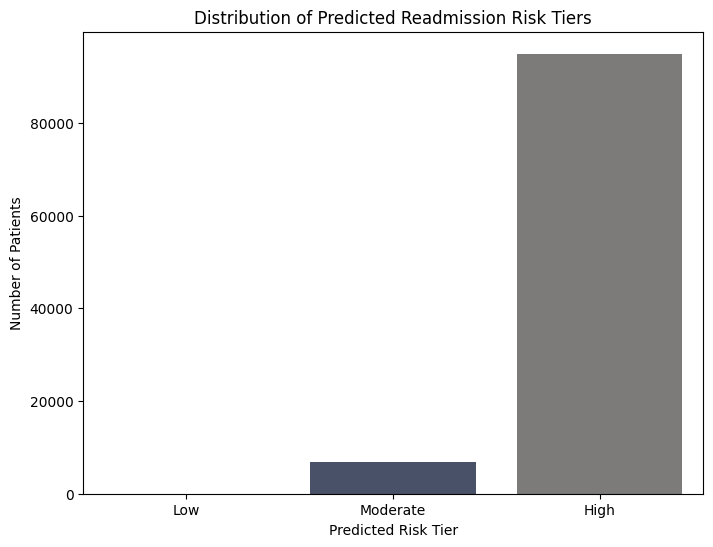

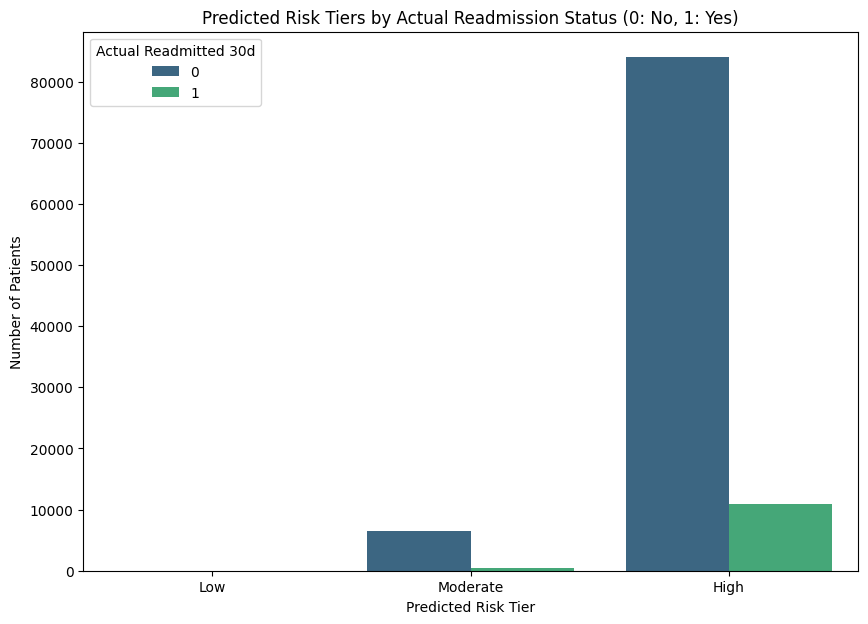

Cohort charts generated for risk distribution.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Start: Code moved from d0af1e39 to ensure patient_features_df has required columns ---
# Assuming patient_features_df, feature_cols, and model_optimized are available from previous cells.

# Prepare the full dataset for prediction
X_full = patient_features_df[feature_cols]

# Get predicted probabilities from the optimized model
predicted_proba_full = model_optimized.predict_proba(X_full)[:, 1]

# Assign risk tiers based on the same thresholds used in agent_ml_predictor_optimized
def assign_risk_tier(prob):
    if prob > 0.4:
        return 'High'
    elif prob > 0.2:
        return 'Moderate'
    else:
        return 'Low'

patient_features_df['predicted_readmission_probability'] = predicted_proba_full
patient_features_df['predicted_risk_tier'] = patient_features_df['predicted_readmission_probability'].apply(assign_risk_tier)

print("Predicted risk tiers assigned to the full dataset (within plotting cell for robustness).")
# --- End: Code moved ---

# Order the risk tiers for consistent plotting
risk_tier_order = ['Low', 'Moderate', 'High']

# Plot 1: Distribution of Predicted Risk Tiers
plt.figure(figsize=(8, 6))
sns.countplot(x='predicted_risk_tier', hue='predicted_risk_tier', data=patient_features_df, order=risk_tier_order, palette='cividis', legend=False)
plt.title('Distribution of Predicted Readmission Risk Tiers')
plt.xlabel('Predicted Risk Tier')
plt.ylabel('Number of Patients')
plt.show()

# Plot 2: Predicted Risk Tiers vs. Actual Readmission Status
plt.figure(figsize=(10, 7))
sns.countplot(x='predicted_risk_tier', hue='readmitted_30d', data=patient_features_df, order=risk_tier_order, palette='viridis')
plt.title('Predicted Risk Tiers by Actual Readmission Status (0: No, 1: Yes)')
plt.xlabel('Predicted Risk Tier')
plt.ylabel('Number of Patients')
plt.legend(title='Actual Readmitted 30d')
plt.show()

print("Cohort charts generated for risk distribution.")

# **Let's Try The Output of the system for each patient using 'patient_nbr'**

In [ ]:
sample_patient_nbr = 18450315

# Define hypothetical hospital protocols
hospital_specific_protocols = (
    "All moderate-to-high risk patients must have a social worker consultation "
    "and a telehealth follow-up scheduled within 72 hours of discharge. "
    "Medication reconciliation must be completed by a pharmacist."
)

# Agent 1: SQL & Data Extractor
vitals_opt_v2 = agent_sql_extractor(sample_patient_nbr)
print(f"Extracted Vitals for Patient {sample_patient_nbr}: {vitals_opt_v2}")

# Agent 2: Clinical ML Predictor (Using the OPTIMIZED model)
# This remains the same as our best performing ML agent
ml_results_optimized_v2 = agent_ml_predictor_optimized(vitals_opt_v2)
print(f"ML Prediction Results for Patient {sample_patient_nbr} (Optimized Model): {ml_results_optimized_v2}")

# Agent 3: BI & Executive Synthesizer (Using the NEW, tailored version)
executive_brief_tailored = agent_executive_synthesizer_v2(
    sample_patient_nbr, vitals_opt_v2, ml_results_optimized_v2,
    hospital_protocols=hospital_specific_protocols
)
print(f"""
Executive Clinical Brief for Patient {sample_patient_nbr} (Tailored Model):
{executive_brief_tailored}
""")

Extracted Vitals for Patient 18450315: {'time_in_hospital': 6, 'num_lab_procedures': 80, 'num_medications': 15, 'number_emergency': 0}
ML Prediction Results for Patient 18450315 (Optimized Model): {'readmission_probability': 0.4981, 'risk_tier': 'High', 'top_drivers': ['time_in_hospital (impact: +0.101)', 'num_lab_procedures (impact: -0.074)', 'number_emergency (impact: -0.056)']}

Executive Clinical Brief for Patient 18450315 (Tailored Model):
**Executive Clinical Brief – Patient 18450315**

---

### 1. Executive Risk Summary  
- **Risk Tier:** **High**  
- **Readmission Probability:** **49.8 %**  

The model flags this patient as high‑risk for 30‑day readmission, triggering mandatory transition‑of‑care safeguards.

---

### 2. Primary Contributing Drivers  

| SHAP Driver | Direction & Magnitude | Clinical Interpretation |
|-------------|----------------------|--------------------------|
| **Time in hospital (+0.101)** | Positive impact – longer stay ↑ risk | A 6‑day admission sugges

In [ ]:
import time
from groq import RateLimitError

sample_patient_nbr = 12629988

# Define hypothetical hospital protocols
hospital_specific_protocols = (
    "All moderate-to-high risk patients must have a social worker consultation "
    "and a telehealth follow-up scheduled within 72 hours of discharge. "
    "Medication reconciliation must be completed by a pharmacist."
)

# Agent 1: SQL & Data Extractor
vitals_opt_v2 = agent_sql_extractor(sample_patient_nbr)
print(f"Extracted Vitals for Patient {sample_patient_nbr}: {vitals_opt_v2}")

# Agent 2: Clinical ML Predictor (Using the OPTIMIZED model)
ml_results_optimized_v2 = agent_ml_predictor_optimized(vitals_opt_v2)
print(f"ML Prediction Results for Patient {sample_patient_nbr} (Optimized Model): {ml_results_optimized_v2}")

# Agent 3: BI & Executive Synthesizer with Rate Limit Handling
try:
    executive_brief_tailored = agent_executive_synthesizer_v2(
        sample_patient_nbr, vitals_opt_v2, ml_results_optimized_v2,
        hospital_protocols=hospital_specific_protocols
    )
    print(f"\nExecutive Clinical Brief for Patient {sample_patient_nbr} (Tailored Model):\n{executive_brief_tailored}")
except RateLimitError as e:
    print(f"\n[!] Rate Limit Reached: {e.message}")
    print("Please wait a few seconds before re-running this cell to allow the token quota to reset.")
except Exception as e:
    print(f"\n[!] An unexpected error occurred: {e}")

Extracted Vitals for Patient 12629988: {'time_in_hospital': 8, 'num_lab_procedures': 67, 'num_medications': 24, 'number_emergency': 0}
ML Prediction Results for Patient 12629988 (Optimized Model): {'readmission_probability': 0.5519, 'risk_tier': 'High', 'top_drivers': ['time_in_hospital (impact: +0.164)', 'num_medications (impact: +0.106)', 'number_emergency (impact: -0.061)']}

Executive Clinical Brief for Patient 12629988 (Tailored Model):
**Executive Clinical Brief – Patient 12629988**

---

### 1. Executive Risk Summary  
- **Risk Tier:** **High**  
- **Readmission Probability:** **55.2 %**  

The patient falls into the high‑risk category, triggering mandatory transition‑of‑care safeguards per hospital protocol.

---

### 2. Primary Contributing Drivers  

| SHAP Driver | Clinical Interpretation | How It Elevates Readmission Risk |
|-------------|------------------------|----------------------------------|
| **Time in hospital (8 days, +0.164)** | Prolonged admission often reflects

In [ ]:
# 23608431
sample_patient_nbr = 23608431

# Define hypothetical hospital protocols
hospital_specific_protocols = (
    "All moderate-to-high risk patients must have a social worker consultation "
    "and a telehealth follow-up scheduled within 72 hours of discharge. "
    "Medication reconciliation must be completed by a pharmacist."
)

# Agent 1: SQL & Data Extractor
vitals_opt_v2 = agent_sql_extractor(sample_patient_nbr)
print(f"Extracted Vitals for Patient {sample_patient_nbr}: {vitals_opt_v2}")

# Agent 2: Clinical ML Predictor (Using the OPTIMIZED model)
# This remains the same as our best performing ML agent
ml_results_optimized_v2 = agent_ml_predictor_optimized(vitals_opt_v2)
print(f"ML Prediction Results for Patient {sample_patient_nbr} (Optimized Model): {ml_results_optimized_v2}")

# Agent 3: BI & Executive Synthesizer (Using the NEW, tailored version)
executive_brief_tailored = agent_executive_synthesizer_v2(
    sample_patient_nbr, vitals_opt_v2, ml_results_optimized_v2,
    hospital_protocols=hospital_specific_protocols
)
print(f"""
Executive Clinical Brief for Patient {sample_patient_nbr} (Tailored Model):
{executive_brief_tailored}
""")

Extracted Vitals for Patient 23608431: {'time_in_hospital': 3, 'num_lab_procedures': 18, 'num_medications': 13, 'number_emergency': 2}
ML Prediction Results for Patient 23608431 (Optimized Model): {'readmission_probability': 0.6546, 'risk_tier': 'High', 'top_drivers': ['number_emergency (impact: +0.659)', 'time_in_hospital (impact: -0.011)', 'num_medications (impact: -0.008)']}

Executive Clinical Brief for Patient 23608431 (Tailored Model):
**Executive Clinical Brief – Patient 23608431**

---

### 1. Executive Risk Summary  
- **Risk Tier:** **High**  
- **Readmission Probability:** **65.5 %**  

---

### 2. Primary Contributing Drivers  
| SHAP Driver | Model Impact | Clinical Interpretation |
|-------------|--------------|--------------------------|
| **Number of Emergency Visits** (+0.659) | Strong positive contribution | Two ED visits in the past period signal clinical instability, possible uncontrolled symptoms, or gaps in outpatient management – the dominant factor driving readm

In [ ]:
# 908091
sample_patient_nbr = 908091

# Define hypothetical hospital protocols
hospital_specific_protocols = (
    "All moderate-to-high risk patients must have a social worker consultation "
    "and a telehealth follow-up scheduled within 72 hours of discharge. "
    "Medication reconciliation must be completed by a pharmacist."
)

# Agent 1: SQL & Data Extractor
vitals_opt_v2 = agent_sql_extractor(sample_patient_nbr)
print(f"Extracted Vitals for Patient {sample_patient_nbr}: {vitals_opt_v2}")

# Agent 2: Clinical ML Predictor (Using the OPTIMIZED model)
# This remains the same as our best performing ML agent
ml_results_optimized_v2 = agent_ml_predictor_optimized(vitals_opt_v2)
print(f"ML Prediction Results for Patient {sample_patient_nbr} (Optimized Model): {ml_results_optimized_v2}")

# Agent 3: BI & Executive Synthesizer (Using the NEW, tailored version)
executive_brief_tailored = agent_executive_synthesizer_v2(
    sample_patient_nbr, vitals_opt_v2, ml_results_optimized_v2,
    hospital_protocols=hospital_specific_protocols
)
print(f"""
Executive Clinical Brief for Patient {sample_patient_nbr} (Tailored Model):
{executive_brief_tailored}
""")

In [ ]:
import json
import os
from google.colab import userdata
from groq import Groq

# Securely retrieve the API key
GROQ_API_KEY = userdata.get('GROQ_API_KEY')
groq_client = Groq(api_key=GROQ_API_KEY)

sample_patient_nbr = 74528739

# Agent 1: SQL & Data Extractor
vitals_dict = agent_sql_extractor(sample_patient_nbr)

# Agent 2: Clinical ML Predictor
ml_results_optimized_v2 = agent_ml_predictor_optimized(vitals_dict)

# Agent 3: BI & Executive Synthesizer
def agent_executive_synthesizer_v3(patient_id, vitals, ml_results, hospital_protocols=""):
    system_instruction = "You are an expert Clinical BI Copilot. Provide structured, executive-ready risk reports."
    if hospital_protocols:
        system_instruction += f" Adhere to: {hospital_protocols}"

    user_prompt = f"Analyze Patient {patient_id}. Metrics: {json.dumps(vitals)}. ML: {json.dumps(ml_results)}."

    chat_completion = groq_client.chat.completions.create(
        model="groq/compound",
        messages=[
            {"role": "system", "content": system_instruction},
            {"role": "user", "content": user_prompt},
        ],
    )
    return chat_completion.choices[0].message.content

executive_brief_tailored = agent_executive_synthesizer_v3(
    sample_patient_nbr, vitals_dict, ml_results_optimized_v2
)
print(f"Analysis for Patient {sample_patient_nbr} completed.")
print("\nExecutive Clinical Brief:\n", executive_brief_tailored)

Analysis for Patient 74528739 completed.

Executive Clinical Brief:
 **Patient 74528739 – Executive‑Ready Readmission Risk Report**

---

### 1. Patient Summary (raw metrics)

| Metric                     | Value |
|----------------------------|-------|
| **Time in hospital**       | 4 days |
| **Number of lab procedures** | 34 |
| **Number of medications**  | 7 |
| **Number of emergency visits** | 0 |

---

### 2. Machine‑Learning Output

| Item                         | Value |
|------------------------------|-------|
| **Readmission probability**  | **0.4512**  (45.12 %) |
| **Risk tier**                | **High** |
| **Top drivers of risk**      | 1. **num_medications** (impact = ‑0.193)  <br>2. **number_emergency** (impact = ‑0.072)  <br>3. **time_in_hospital** (impact = +0.047) |

*Interpretation of driver signs:*  
- A **negative impact** means that **lower values** of the variable are associated with **higher readmission risk** (e.g., fewer medications → higher risk).  
- A **p

### Testing Pipeline with Patient ID: 55667788
We will now run the SQL Extractor, ML Predictor, and BI Synthesizer for a new sample case.

In [ ]:
import json

# Selecting a new patient ID for testing
test_patient_id = 55667788

# Define hospital protocols
hospital_protocols = (
    "All moderate-to-high risk patients must have a social worker consultation "
    "and a telehealth follow-up scheduled within 72 hours of discharge. "
    "Medication reconciliation must be completed by a pharmacist."
)

try:
    # Agent 1: SQL Extraction
    vitals = agent_sql_extractor(test_patient_id)
    print(f"[Agent 1] Extracted Vitals for {test_patient_id}: {vitals}")

    # Agent 2: ML Prediction (Optimized Model)
    ml_results = agent_ml_predictor_optimized(vitals)
    print(f"[Agent 2] ML Results: {ml_results}")

    # Agent 3: Executive Synthesis
    brief = agent_executive_synthesizer_v2(
        test_patient_id, vitals, ml_results, hospital_protocols=hospital_protocols
    )

    print(f"\n[Agent 3] Executive Clinical Brief:\n{brief}")

except Exception as e:
    print(f"Error processing patient {test_patient_id}: {e}")

[Agent 1] Extracted Vitals for 55667788: {'time_in_hospital': 7, 'num_lab_procedures': 62, 'num_medications': 18, 'number_emergency': 3}
[Agent 2] ML Results: {'readmission_probability': 0.6848, 'risk_tier': 'High', 'top_drivers': ['number_emergency (impact: +0.584)', 'time_in_hospital (impact: +0.083)', 'num_medications (impact: +0.066)']}

[Agent 3] Executive Clinical Brief:
**Executive Clinical Brief – Patient 55667788**

---

### 1. Executive Risk Summary  
- **Risk Tier:** **High**  
- **Readmission Probability:** **68.5 %**  

---

### 2. Primary Contributing Drivers  
| SHAP Driver | Clinical Impact | Why it raises readmission risk |
|-------------|----------------|--------------------------------|
| **Number of emergency visits (+0.584)** | 3 ED visits in the past period | Indicates unstable disease control, frequent acute decompensation, and possible gaps in outpatient management. |
| **Time in hospital (+0.083)** | 7 days stay | Reflects a complex or severe index admission; l

# **Cost-Benefit Analysis**

Assumptions and Calulations for a Mid-sized hospital in USA:

For an average medium-sized facility, annual Medicare DRG revenue is  approximately $40 million. HRRP Payment Adjustment Factor approximately 1.5%

Baseline HRRP Penalty = $40,000,000 (forty million)* 0.015 = $600,000  

Our Recall is 54.18%
So, Baseline HRRP Penalty $600,000 * 0.5418 =  $325,080

In reality, the intervention won't prevent 100% of the readmissions among the 1,238 true positives. Let's introduce an intervention effectiveness rate. Suppose the intervention prevents 60% of the readmissions among correctly identified high-risk patients.

So Multiplying the 1,238 True Positive patients by the 0.60 sucess/effectiveness rate yields 1238 * 0.60 = 742.8 or 743 patients prevented readmissions.

Multiplying the theoretical maximum penalty savings of 325,080 by the 0.60 effectiveness rate yields $325,080 * 0.60 = $195,048

Total patients flagged (True Positives + False Positives): 1,238 + 8,007 = 9,245 patients

Assume, Maximum Cost per intervention: $150

Total Intervention Cost: 9,245 × $150 = $1,386,750

Readmissions Successfully Prevented: 1,238 true risk patients × 0.60 (60% success rate) = 742.8 prevented readmissions.

Estimate ($2,400 / prevented  readmission): 742.8  patients × $2,400 = $1,782,720.

Net Benefit = (HRRP Savings + Acute Inpatient Savings) - Total Intervention Cost   

= 195,048 +  $1,782,720 - $1,386,750 = $591,018


**Build a sensitivity analysis**

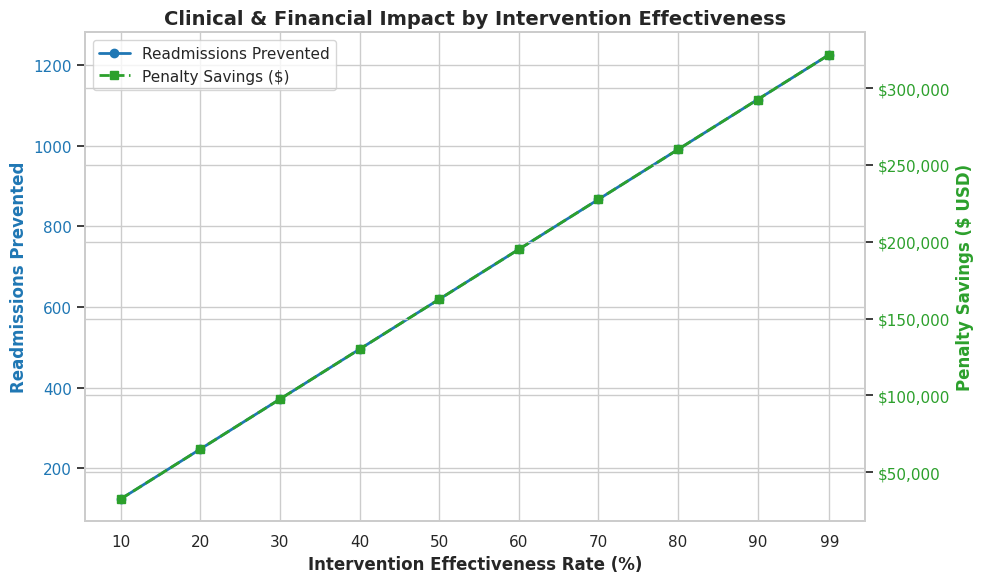

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Constructing our dataset
data = {
    'Effectiveness_Rate_Pct': [10, 20, 30, 40, 50, 60, 70, 80, 90, 99],
    'Readmissions_Prevented': [123.8, 247.6, 371.4, 495.2, 619.0, 742.8, 866.6, 990.4, 1114.2, 1225.62],
    'Penalty_Savings_USD': [32508, 65016, 97524, 130032, 162540, 195048, 227556, 260064, 292572, 321829.2]
}
df = pd.DataFrame(data)

# Configuring the plotting style
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot 1: Readmissions Prevented (Left Y-Axis)
color1 = 'tab:blue'
ax1.set_xlabel('Intervention Effectiveness Rate (%)', fontweight='bold')
ax1.set_ylabel('Readmissions Prevented', color=color1, fontweight='bold')
line1 = ax1.plot(df['Effectiveness_Rate_Pct'], df['Readmissions_Prevented'],
                 color=color1, marker='o', linewidth=2, label='Readmissions Prevented')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(df['Effectiveness_Rate_Pct'])

# Plot 2: Penalty Savings (Right Y-Axis)
ax2 = ax1.twinx()
color2 = 'tab:green'
ax2.set_ylabel('Penalty Savings ($ USD)', color=color2, fontweight='bold')
line2 = ax2.plot(df['Effectiveness_Rate_Pct'], df['Penalty_Savings_USD'],
                 color=color2, marker='s', linestyle='--', linewidth=2, label='Penalty Savings ($)')
ax2.tick_params(axis='y', labelcolor=color2)

# Formatting the Y-axis for currency
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))

# Combining legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Clinical & Financial Impact by Intervention Effectiveness', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The dual-axis line chart models the direct, linear correlation between clinical intervention success rates and their corresponding clinical and financial returns.

**Intervention Effectiveness (X-Axis):** Plots the assumed success rate of the clinical intervention, ranging from 10% to 99%.

**Readmissions Prevented (Left Y-Axis):** The solid blue line tracks the volume of successfully avoided readmissions, which scales uniformly with higher effectiveness.

**Penalty Savings (Right Y-Axis):** The dashed green line maps the financial impact, showing how prevented readmissions translate proportionally into avoided Medicare penalties.

**Correlated Growth:** The overlapping trajectories indicate that any percentage increase in clinical efficacy yields a predictable, directly proportional gain in both patient health outcomes and hospital cost savings.

**Patient Flow Sankey Diagram:**  

This code maps the patient journey from the initial model flags down to the final intervention outcomes.

In [ ]:
import plotly.graph_objects as go

# Define the nodes and flow values for the patient population
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 20,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = [
          "Total Flagged (9,245)",
          "False Positives (8,007)",
          "True Positives (1,238)",
          "Prevented Readmissions (743)",
          "Unprevented (495)"
      ],
      color = ["#1f77b4", "#d62728", "#2ca02c", "#2ca02c", "#ff7f0e"]
    ),
    link = dict(
      source = [0, 0, 2, 2],
      target = [1, 2, 3, 4],
      value =  [8007, 1238, 743, 495],
      color = ["rgba(214, 39, 40, 0.3)", "rgba(44, 160, 44, 0.4)", "rgba(44, 160, 44, 0.6)", "rgba(255, 127, 14, 0.3)"]
  ))])

fig.update_layout(
    title_text="Patient Stratification & Intervention Effectiveness",
    font_size=14,
    width=800,
    height=500
)

fig.show()

**This Sankey diagram** illustrates the flow of patients from the model's initial risk flagging through to the final clinical outcomes, highlighting the real-world attrition caused by false positives and intervention failure rates.

**Total Patient Funnel:**

Total Flagged (9,245): The initial pool of patients identified by the model as high-risk and targeted for clinical intervention.

**Model Accuracy Breakdown**

**False Positives (8,007):** The majority of flagged patients would not have been readmitted anyway. This wide pink/red band visualizes the operational cost or "noise" the hospital must absorb and fund to capture the true risk group.

**True Positives (1,238):** The subset of patients correctly identified as high-risk who genuinely required the intervention.

**Intervention Outcomes**

**Prevented Readmissions (743):** Among the 1,238 True Positives, the intervention successfully stopped readmission for this group (reflecting a 60% effectiveness rate). This green path represents the actual clinical and financial success of the program.

**Unprevented (495):** The remaining correctly identified high-risk patients who were still readmitted despite receiving the preventative intervention.

**Financial Net Benefit Waterfall Chart**


This code calculates the step-by-step additions (savings) and subtractions (costs) to arrive at your final net benefit.

In [ ]:
import plotly.graph_objects as go

# Define the financial metrics and step types
fig = go.Figure(go.Waterfall(
    name = "Financial Impact",
    orientation = "v",
    measure = ["relative", "relative", "relative", "total"],
    x = ["HRRP Savings", "Acute Inpatient Savings", "Total Intervention Cost", "Net Benefit"],
    textposition = "outside",
    text = ["+$195K", "+$1.78M", "-$1.38M", "+$591K"],
    y = [195048, 1782720, -1386750, 591018],
    connector = {"line":{"color":"rgb(63, 63, 63)"}},
    decreasing = {"marker":{"color":"#d62728"}},
    increasing = {"marker":{"color":"#2ca02c"}},
    totals = {"marker":{"color":"#1f77b4"}}
))

fig.update_layout(
    title="Financial Impact of Readmission Intervention",
    showlegend=False,
    width=800,
    height=500
)

fig.show()

**The waterfall chart** visualizes the step-by-step financial impact of the readmission intervention, showing how operational costs offset projected savings to produce a positive return on investment.

**Gross Savings**

**HRRP Savings (+$195K):** Represents the avoided Medicare penalty fines due to a reduced readmission rate.

**Acute Inpatient Savings (+$1.78M):** The bulk of the financial benefit, stemming from the direct cost savings of avoiding inpatient care for prevented readmissions.

**Program Expenses**

**Total Intervention Cost (-$1.38M):** The cumulative cost required to administer the preventative intervention to all patients initially flagged by the model.

**Final Outcome**

**Net Benefit (+$591K):** The bottom-line financial value of the program, demonstrating that the combined savings significantly outweigh the operational intervention costs.